In [1]:
import sys, os

## Include previous level directories to the module import path
sys.path.insert(0, os.path.abspath(os.path.join("..")))

# import arviz as az
import numpy as np
import h5py

# Export the results to GetDist

# Notice loadMCSamples requires a *full path*
import os
from matplotlib import pyplot as plt
import matplotlib

from matplotlib import cm

matplotlib.rcParams.update(
    {
        "font.size": 16,
        "axes.labelsize": 24,
        "axes.titlesize": 18,
        "text.usetex": True,
        "xtick.major.width": 1.5,
        "xtick.minor.width": 1.2,
        "ytick.major.width": 1.5,
        "ytick.minor.width": 1.2,
        "legend.fontsize": 18,
    }
)

# Deep purples / indigos
c_flatirons = "#440154"
c_flatirons_l = "#472d7b"
c_flatirons_ll = "#3b528b"

# Teal / cyan region
c_sunshine = "#2a788e"
c_sunshine_l = "#21908d"
c_sunshine_ll = "#20a386"

# Green-cyan (maximum brightness allowed)
c_skyline = "#35b779"
c_skyline_l = "#5ec962"  # Cap brightness here
# c_skyline_ll = omitted due to low print contrast

# Blue highlight
c_midnight = "#31688e"


cmap = cm.get_cmap("viridis")

# change fontsize
matplotlib.rcParams.update(
    {"font.size": 12, "axes.labelsize": 16, "axes.titlesize": 14}
)

# matplotlib.use('PDF')
save_figure = lambda filename: plt.savefig(
    "{}.pdf".format(filename), format="pdf", dpi=300
)

outfile = "../cddf_all/"


/var/folders/sn/b7hd1bmd569cjwgmtww4mv440000gn/T/ipykernel_98577/702180666.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


In [2]:
sys.path.insert(0, os.path.abspath(os.path.join("../../DLA_data")))
import dla_data

In [3]:
# CDDF mock code

from CDDF_analysis.cddf_mock import *

In [4]:

import numpy as np
from scipy.interpolate import PchipInterpolator

# From Table 2 (Results for Spline Model — Figure 7)
logN_nodes = np.array([12.0, 15.0, 17.0, 18.0, 
                       20.0, 21.0, 21.5, 22.0])
logf_nodes = np.array([-9.72, -14.41, -17.94, -19.39,
                       -21.28, -22.82, -23.95, -25.50])

# Paper specifies cubic Hermite spline (Fritsch & Carlson 1980)
cddf_spline = PchipInterpolator(logN_nodes, logf_nodes)

def log10_f_cddf(logN):
    """
    CDDF used in Figure 7 of Prochaska et al. 2014.
    A cubic Hermite spline defined by Table 2 (Spline Model).
    """
    logN = np.asarray(logN)
    logN_clip = np.clip(logN, logN_nodes[0], logN_nodes[-1])
    return cddf_spline(logN_clip)

def f_cddf(logN):
    return 10**log10_f_cddf(logN)


## GP-LLS

In [5]:
def zbins_from_zmid_uniform(z_mid):
    z_mid = np.asarray(z_mid, dtype=float)
    dz = np.median(np.diff(z_mid))   # robust
    zbins = np.concatenate([
        [z_mid[0] - 0.5 * dz],
        z_mid + 0.5 * dz
    ])
    return zbins



def plot_line_density(
    z_cent: np.ndarray,
    dNdX: np.ndarray,
    dndx68: np.ndarray,
    dndx95: np.ndarray,
    zmin: float = 2.0,
    zmax: float = 5.5,
    label: str = "GP",
    color="blue",
    bins_per_z: int = 6,
    use_zcent_for_xerr: bool = True,
):
    """Plot the line density as a function of redshift"""
    if use_zcent_for_xerr:
        z_bins = zbins_from_zmid_uniform(z_cent)
    else:
        # Get the redshifts
        nbins = np.max([int((zmax - zmin) * bins_per_z), 1])
        z_bins = np.linspace(zmin, zmax, nbins + 1)

        # try match the zmax : sometimes not enough z bins to reach zmax
        # cut off the extra part until z_bins just larger than last z_cent
        # remove the last bin edge
        ind = z_bins > z_cent[-1]
        z_bins = z_bins[: np.where(ind)[0][0] + 1]

    try:
        # hope this line works
        xerrs = (z_cent - z_bins[:-1], z_bins[1:] - z_cent)
    except ValueError as e:
        xerrs = (z_cent - z_bins[:-2], z_bins[1:-1] - z_cent)

    # 2 sigma contours.
    plt.fill_between(z_cent, dndx95[:, 0], dndx95[:, 1], color="grey", alpha=0.5)
    yerr = (dNdX - dndx68[:, 0], dndx68[:, 1] - dNdX)
    plt.errorbar(z_cent, dNdX, yerr=yerr, xerr=xerrs, fmt="o", color=color, label=label)
    plt.xlabel(r"z")
    plt.ylabel(r"dN/dX")
    plt.xlim(zmin, zmax)

def plot_omega_dla(
    z_cent: np.ndarray,
    omega_dla: np.ndarray,
    omega_dla_68: np.ndarray,
    omega_dla_95: np.ndarray,
    zmin: float = 2.0,
    zmax: float = 5.5,
    label: str = "GP",
    color: str = "blue",
    twosigma: bool = True,
    bins_per_z: int = 6,
    ylabel: str = r"$10^3 \times \Omega_\mathrm{subDLA}$",
    use_zcent_for_xerr: bool = True,
):
    """Plot omega_DLA as a function of redshift, with full Bayesian errors"""
    if use_zcent_for_xerr:
        z_bins = zbins_from_zmid_uniform(z_cent)
    else:
        # Get the redshifts
        nbins = np.max([int((zmax - zmin) * bins_per_z), 1])
        z_bins = np.linspace(zmin, zmax, nbins + 1)

        # try match the zmax : sometimes not enough z bins to reach zmax
        # cut off the extra part until z_bins just larger than last z_cent
        # remove the last bin edge
        ind = z_bins > z_cent[-1]
        z_bins = z_bins[: np.where(ind)[0][0] + 1]

    try:
        # hope this line works
        xerrs = (z_cent - z_bins[:-1], z_bins[1:] - z_cent)
    except ValueError as e:
        xerrs = (z_cent - z_bins[:-2], z_bins[1:-1] - z_cent)

    # import pdb
    # pdb.set_trace()

    if twosigma:
        plt.fill_between(
            z_cent,
            1000 * omega_dla_95[:, 0],
            1000 * omega_dla_95[:, 1],
            color="grey",
            alpha=0.5,
        )
    yerr = (
        omega_dla - 1000 * omega_dla_68[:, 0],
        1000 * omega_dla_68[:, 1] - omega_dla,
    )
    plt.errorbar(
        z_cent, omega_dla, yerr=yerr, xerr=xerrs, fmt="s", label=label, color=color
    )
    plt.xlabel(r"z")
    plt.ylabel(ylabel)
    plt.xlim(zmin, zmax)


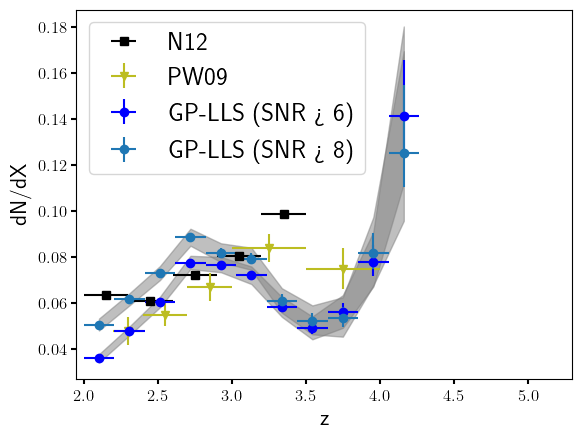

In [6]:

# Load DLA data Noterdaeme 2012, Prochaska 2005
dla_data.dndx_not()
dla_data.dndx_pro()

subdir = "/Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/cddf_all/dla_cddf_20260107/desi_snr6.0_zqsos_2.15-5.0_dla_5.5_occam_1.0_dla_model_1_zminlyb_22.0_minobswave_3700.0_bins_5_lnhi_17.2-22.0_lnhi_dndx_17.2-19.0/"

# dN/dX: Fiducial
dndx_all = np.loadtxt(os.path.join(subdir, "dndx_all.txt"))
(_, N) = dndx_all.shape

dndx68 = np.full((N, 2), fill_value=np.nan)
dndx95 = np.full((N, 2), fill_value=np.nan)
(
    z_cent,
    dNdX,
    dndx68[:, 0],
    dndx68[:, 1],
    dndx95[:, 0],
    dndx95[:, 1],
) = dndx_all

plot_line_density(z_cent, dNdX, dndx68, dndx95, color="blue", label="GP-LLS (SNR > 6)", bins_per_z=5, zmin=2, zmax=4.25)

# dN/dX: High SNR
high_snrsubdir = "/Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/cddf_all/dla_cddf_20260107/desi_snr8.0_zqsos_2.15-5.0_dla_5.5_occam_1.0_dla_model_1_zminlyb_22.0_minobswave_3700.0_bins_5_lnhi_17.2-22.0_lnhi_dndx_17.2-19.0/"
dndx_all = np.loadtxt(os.path.join(high_snrsubdir, "dndx_all.txt"))
(_, N) = dndx_all.shape

dndx68 = np.full((N, 2), fill_value=np.nan)
dndx95 = np.full((N, 2), fill_value=np.nan)
(
    z_cent,
    dNdX,
    dndx68[:, 0],
    dndx68[:, 1],
    dndx95[:, 0],
    dndx95[:, 1],
) = dndx_all

plot_line_density(z_cent, dNdX, dndx68, dndx95, color="C0", label="GP-LLS (SNR > 8)", bins_per_z=5, zmin=2, zmax=4.25)

plt.xlim(1.95, 5.3)
plt.legend()

save_figure(os.path.join(outfile, "dndx_lls"))

## Truth mock

In [7]:
from astropy.table import Table

dla_cat = Table.read(
    "/Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/data/london/dla_cat.fits"
)
qso_cat = Table.read(
    "/Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/data/london/zcat.fits"
)

In [8]:
import numpy as np

# --- choose redshift bins ---
# zbins = np.array([2.0, 2.5, 3.0, 3.5, 4.0])
zbins = zbins_from_zmid_uniform(z_cent)

# --- common analysis settings ---
common = dict(
    zbins=zbins,
    zmin=2.0,
    zmax_global=None,
    v_prox_kms=3000.0,
    Omega_m=0.279,
    assume_logNHI=True,
    n_boot=200,   # set 0 to skip bootstrap
)

# --- LLS dN/dX ---
out_lls = compute_dndx(
    dla_cat, qso_cat,
    logNHImin=17.2, logNHImax=19.0,
    **common
)

# --- subDLA dN/dX ---
out_subdla = compute_dndx(
    dla_cat, qso_cat,
    logNHImin=19.0, logNHImax=20.3,
    **common
)

# --- DLA dN/dX ---
out_dla = compute_dndx(
    dla_cat, qso_cat,
    logNHImin=20.3, logNHImax=23.0,
    **common
)

print("z_mid:", out_dla["z_mid"])
print("DLA dN/dX:", out_dla["dndx"], "Poisson:", out_dla["err_poisson"], "Boot:", out_dla["err_boot"])

/Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/CDDF_analysis/cddf_mock.py:259: RuntimeWarning: invalid value encountered in divide
  dndx = np.where(X_tot > 0, N_abs / X_tot, np.nan)
/Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/CDDF_analysis/cddf_mock.py:260: RuntimeWarning: invalid value encountered in divide
  err_pois = np.where(X_tot > 0, np.sqrt(N_abs) / X_tot, np.nan)
/Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/CDDF_analysis/cddf_mock.py:293: RuntimeWarning: invalid value encountered in divide
  boot[b] = np.where(Xb > 0, Nb / Xb, np.nan)
/Users/jibanmac/Documents/conda/desispec/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


z_mid: [2.10294118 2.30882353 2.51470588 2.72058824 2.92647059 3.13235294
 3.33823529 3.54411765 3.75       3.95588235 4.16176471]
DLA dN/dX: [0.05019598 0.05484642 0.0593587  0.06429928 0.07025672 0.07780421
 0.08396174 0.08361545 0.09665109        nan        nan] Poisson: [0.00031835 0.00039471 0.00050544 0.00065581 0.00088501 0.00126066
 0.00191317 0.00312704 0.01018792        nan        nan] Boot: [0.00035341 0.00037501 0.00049831 0.00065355 0.00096622 0.00122644
 0.00201641 0.00324421 0.00980979        nan        nan]


In [9]:
logN_bins_lls = np.arange(17.2, 22 + 1e-6, 0.2)

cddf_lls = compute_cddf_fN(
    dla_cat, qso_cat,
    zbins=zbins,
    logN_bins=logN_bins_lls,
    zmin=2.0,
    v_prox_kms=3000.0,
    Omega_m=0.279,
    logNHImin=17.2, logNHImax=22,  # truncate to LLS
    assume_logNHI=True,
    n_boot=200,
)

# f has shape (n_zbins, n_logN_bins-1)
# print("LLS CDDF f shape:", cddf_lls["f"].shape)

In [10]:
# 1) Omega_HI for LLS only (e.g. logN>=17.2)
out_omega_lls = omega_hi_from_cddf(
    cddf_lls,
    logN_min=17.2,
    logN_max=19.0,
    H0_km_s_Mpc=70.0,     # or whatever you want
    prefer_boot=True,
)

# 2) Omega_HI for subDLA (e.g. logN>=17.2)
out_omega_subdla = omega_hi_from_cddf(
    cddf_lls,
    logN_min=19.0,
    logN_max=20.3,
    H0_km_s_Mpc=70.0,     # or whatever you want
    prefer_boot=True,
)

# Omega_HI for DLAs only (e.g. logN>=20.3)
out_omega_dla = omega_hi_from_cddf(
    cddf_lls,
    logN_min=20.3,
    logN_max=22.0,
    H0_km_s_Mpc=70.0,     # or whatever you want
    prefer_boot=True,
)

# plot_omega_hi(out_omega_dla, label="$\Omega_{HI} (DLA)$)")
# plot_omega_hi(out_omega_subdla, label="$\Omega_{HI} (subDLA)$")
# plot_omega_hi(out_omega_lls, label="$\Omega_{HI} (LLS)$)")

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Helpers
# ----------------------------

def _pick_err(err_poisson, err_boot=None, prefer_boot=True):
    """Return the error array to plot."""
    if prefer_boot and (err_boot is not None):
        return err_boot
    return err_poisson


# ----------------------------
# 7) Optional: plotting utilities (matplotlib)
# ----------------------------

def plot_dndx(out, *, label=None, prefer_boot=True, ax=None, show=True):
    import matplotlib.pyplot as plt

    z = out["z_mid"]
    y = out["dndx"]
    yerr = out["err_boot"] if (prefer_boot and out.get("err_boot") is not None) else out["err_poisson"]

    # xerr from zbins
    zb = out["zbins"]
    xerr = 0.5 * (zb[1:] - zb[:-1])

    if ax is None:
        fig, ax = plt.subplots()

    ax.errorbar(z, y, yerr=yerr, xerr=xerr, fmt="o", capsize=2, label=label)
    ax.set_xlabel("z")
    ax.set_ylabel(r"$dN/dX$")
    ax.grid(True, alpha=0.3)
    if label:
        ax.legend()
    if show:
        plt.show()
    return ax


def plot_cddf_slice_fN(out, zbin_index, *, label=None, prefer_boot=True, ax=None, show=True, ylog=True):
    """
    Plot f(N) vs log10 N at a chosen z-bin index.
    """
    import matplotlib.pyplot as plt

    x = out["logN_mid"]
    y = out["fN"][zbin_index]
    yerr = out["err_boot"][zbin_index] if (prefer_boot and out.get("err_boot") is not None) else out["err_poisson"][zbin_index]

    if ax is None:
        fig, ax = plt.subplots()

    ax.errorbar(x, y, yerr=yerr, fmt="o", capsize=2, label=label)
    ax.set_xlabel(r"$\log_{10} N_{\rm HI}$")
    ax.set_ylabel(r"$f(N)=d^2N/(dN\,dX)$  [cm$^2$]")
    ax.grid(True, alpha=0.3)
    if ylog:
        ax.set_yscale("log")
    if label:
        ax.legend()
    if show:
        plt.show()
    return ax

Text(0.5, 1.0, 'Line density: dN/dX')

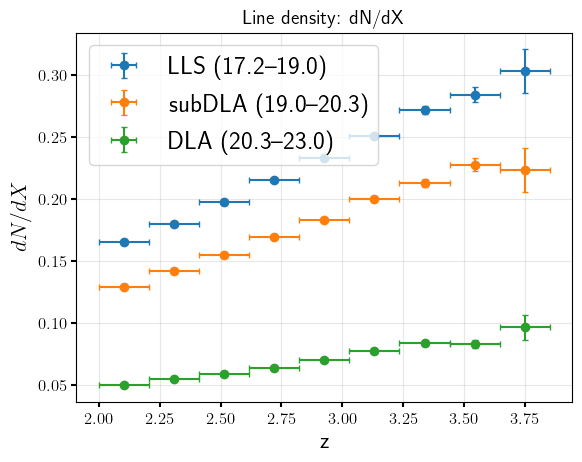

In [12]:
# ------------------------------------------------------------
# 2) Plot dN/dX (overlay)
# ------------------------------------------------------------
fig, ax = plt.subplots()
plot_dndx(out_lls, label="LLS (17.2–19.0)", prefer_boot=True, ax=ax, show=False)
plot_dndx(out_subdla, label="subDLA (19.0–20.3)", prefer_boot=True, ax=ax, show=False)
plot_dndx(out_dla, label="DLA (20.3–23.0)", prefer_boot=True, ax=ax, show=False)
ax.set_title("Line density: dN/dX")


Text(0.5, 1.0, 'Cosmic HI mass density: $\\Omega_{\rm HI}$')

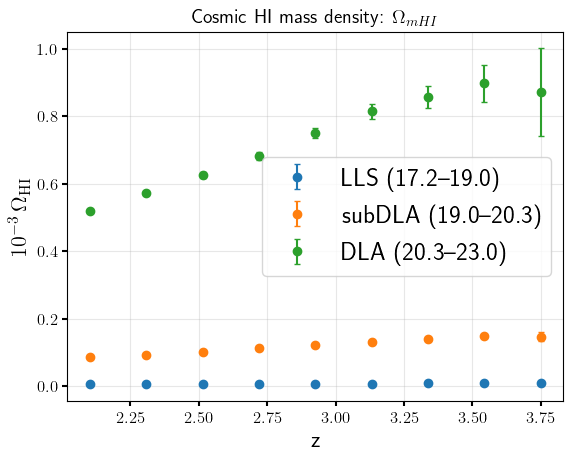

In [13]:
# ------------------------------------------------------------
# 2) Plot OmegaHI (overlay)
# ------------------------------------------------------------
fig, ax = plt.subplots()
plot_omega_hi(out_omega_lls, label="LLS (17.2–19.0)",  ax=ax, show=False)
plot_omega_hi(out_omega_subdla, label="subDLA (19.0–20.3)",  ax=ax, show=False)
plot_omega_hi(out_omega_dla, label="DLA (20.3–23.0)",  ax=ax, show=False)
ax.set_title("Cosmic HI mass density: $\Omega_{\rm HI}$")


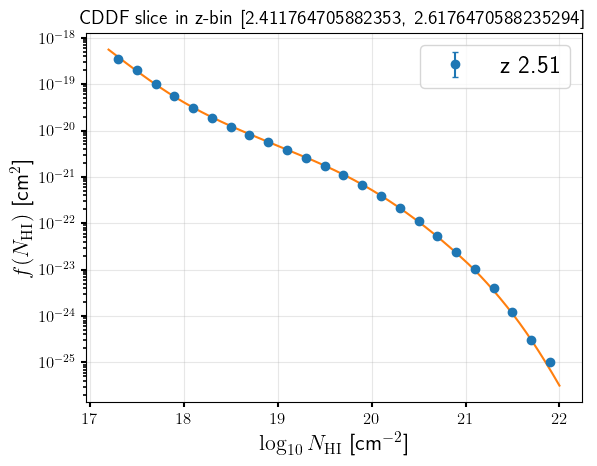

In [14]:
# ------------------------------------------------------------
# 4) Plot one redshift slice of CDDF (overlay)
# Choose z-bin index k (0..len(zbins)-2)
# Example: k=2 corresponds to zbins[2]..zbins[3] = 3.0..3.5
# ------------------------------------------------------------
k = 2

fig, ax = plt.subplots()
plot_cddf_slice_fN(
    cddf_lls, k,
    label=f"z~{cddf_lls['z_mid'][k]:.2f}",
    prefer_boot=True, ax=ax, show=False, ylog=True
)
# plot_cddf_slice_fN(
#     cddf_sub, k,
#     label=f"subDLA z~{cddf_sub['z_mid'][k]:.2f}",
#     prefer_boot=True, ax=ax, show=False, ylog=True
# )
# plot_cddf_slice_fN(
#     cddf_dla, k,
#     label=f"DLA  z~{cddf_dla['z_mid'][k]:.2f}",
#     prefer_boot=True, ax=ax, show=False, ylog=True
# )

# plot the CDDF from Prochaska et al. 2014
logN_plot = np.linspace(17.2, 22.0, 500)
plt.plot(logN_plot, f_cddf(logN_plot), label="Prochaska et al. 2014 CDDF")
plt.yscale("log")
plt.xlabel(r"$\log_{10} N_{\mathrm{HI}}$ [cm$^{-2}$]")
plt.ylabel(r"$f(N_{\mathrm{HI}})$ [cm$^{2}$]")
plt.title("Column Density Distribution Function (CDDF)")

ax.set_title(f"CDDF slice in z-bin [{zbins[k]}, {zbins[k+1]}]")
plt.show()


## Compare with mock measurement

* Lyman limit systems

In [15]:
# London mock
subdir = "/Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/cddf_all/dla_london_cddf_nhi172_20260107/desi_snr6.0_zqsos_2.15-5.0_dla_5.5_occam_1.0_dla_model_1_zminlyb_22.0_minobswave_3700.0_bins_5_lnhi_17.2-22.0_lnhi_dndx_17.2-19.0_z_dla_cddf_min_1.0_z_dla_dndx_min_2.0/"

# dN/dX: Fiducial
dndx_all = np.loadtxt(os.path.join(subdir, "dndx_all.txt"))
(_, N) = dndx_all.shape

dndx68_mock = np.full((N, 2), fill_value=np.nan)
dndx95_mock = np.full((N, 2), fill_value=np.nan)
(
    z_cent_mock,
    dNdX_mock,
    dndx68_mock[:, 0],
    dndx68_mock[:, 1],
    dndx95_mock[:, 0],
    dndx95_mock[:, 1],
) = dndx_all

# OmegaHI: Fiducial
omega_all = np.loadtxt(os.path.join(subdir, "omega_dla_all.txt"))
(_, N_omega) = omega_all.shape

omega68_mock = np.full((N_omega, 2), fill_value=np.nan)
omega95_mock = np.full((N_omega, 2), fill_value=np.nan)
(
    z_cent_omega_mock,
    omega_hi_mock,
    omega68_mock[:, 0],
    omega68_mock[:, 1],
    omega95_mock[:, 0],
    omega95_mock[:, 1],
) = omega_all


######### SNR > 8 #########
# London mock
subdir = "/Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/cddf_all/dla_london_cddf_nhi172_20260107/desi_snr8.0_zqsos_2.15-5.0_dla_5.5_occam_1.0_dla_model_1_zminlyb_22.0_minobswave_3700.0_bins_5_lnhi_17.2-22.0_lnhi_dndx_17.2-19.0_z_dla_cddf_min_1.0_z_dla_dndx_min_2.0/"

# dN/dX: Fiducial
dndx_all = np.loadtxt(os.path.join(subdir, "dndx_all.txt"))
(_, N) = dndx_all.shape

dndx68_mock_highsnr = np.full((N, 2), fill_value=np.nan)
dndx95_mock_highsnr = np.full((N, 2), fill_value=np.nan)
(
    z_cent_mock_highsnr,
    dNdX_mock_highsnr,
    dndx68_mock_highsnr[:, 0],
    dndx68_mock_highsnr[:, 1],
    dndx95_mock_highsnr[:, 0],
    dndx95_mock_highsnr[:, 1],
) = dndx_all

# OmegaHI: Fiducial
omega_all = np.loadtxt(os.path.join(subdir, "omega_dla_all.txt"))
(_, N_omega) = omega_all.shape

omega68_mock_highsnr = np.full((N_omega, 2), fill_value=np.nan)
omega95_mock_highsnr = np.full((N_omega, 2), fill_value=np.nan)
(
    z_cent_omega_mock_highsnr,
    omega_hi_mock_highsnr,
    omega68_mock_highsnr[:, 0],
    omega68_mock_highsnr[:, 1],
    omega95_mock_highsnr[:, 0],
    omega95_mock_highsnr[:, 1],
) = omega_all

# ------------------------------------------------------------



* sub-DLA

In [16]:
# London mock
subdir = "/Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/cddf_all/dla_london_cddf_nhi172_20260107/desi_snr6.0_zqsos_2.15-5.0_dla_5.5_occam_1.0_dla_model_1_zminlyb_22.0_minobswave_3700.0_bins_5_lnhi_17.2-22.0_lnhi_dndx_19.0-20.3"

# dN/dX: Fiducial
dndx_all = np.loadtxt(os.path.join(subdir, "dndx_all.txt"))
(_, N) = dndx_all.shape

dndx68_sub_mock = np.full((N, 2), fill_value=np.nan)
dndx95_sub_mock = np.full((N, 2), fill_value=np.nan)
(
    z_cent_sub_mock,
    dNdX_sub_mock,
    dndx68_sub_mock[:, 0],
    dndx68_sub_mock[:, 1],
    dndx95_sub_mock[:, 0],
    dndx95_sub_mock[:, 1],
) = dndx_all

# OmegaHI: Fiducial
omega_all = np.loadtxt(os.path.join(subdir, "omega_dla_all.txt"))
(_, N_omega) = omega_all.shape

omega68_sub_mock = np.full((N_omega, 2), fill_value=np.nan)
omega95_sub_mock = np.full((N_omega, 2), fill_value=np.nan)
(
    z_cent_omega_sub_mock,
    omega_hi_sub_mock,
    omega68_sub_mock[:, 0],
    omega68_sub_mock[:, 1],
    omega95_sub_mock[:, 0],
    omega95_sub_mock[:, 1],
) = omega_all


######### SNR > 8 #########
# London mock
subdir = "/Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/cddf_all/dla_london_cddf_nhi172_20260107/desi_snr8.0_zqsos_2.15-5.0_dla_5.5_occam_1.0_dla_model_1_zminlyb_22.0_minobswave_3700.0_bins_5_lnhi_17.2-22.0_lnhi_dndx_19.0-20.3/"

# dN/dX: Fiducial
dndx_all = np.loadtxt(os.path.join(subdir, "dndx_all.txt"))
(_, N) = dndx_all.shape

dndx68_sub_mock_highsnr = np.full((N, 2), fill_value=np.nan)
dndx95_sub_mock_highsnr = np.full((N, 2), fill_value=np.nan)
(
    z_cent_sub_mock_highsnr,
    dNdX_sub_mock_highsnr,
    dndx68_sub_mock_highsnr[:, 0],
    dndx68_sub_mock_highsnr[:, 1],
    dndx95_sub_mock_highsnr[:, 0],
    dndx95_sub_mock_highsnr[:, 1],
) = dndx_all

# OmegaHI: Fiducial
omega_all = np.loadtxt(os.path.join(subdir, "omega_dla_all.txt"))
(_, N_omega) = omega_all.shape

omega68_sub_mock_highsnr = np.full((N_omega, 2), fill_value=np.nan)
omega95_sub_mock_highsnr = np.full((N_omega, 2), fill_value=np.nan)
(
    z_cent_omega_sub_mock_highsnr,
    omega_hi_sub_mock_highsnr,
    omega68_sub_mock_highsnr[:, 0],
    omega68_sub_mock_highsnr[:, 1],
    omega95_sub_mock_highsnr[:, 0],
    omega95_sub_mock_highsnr[:, 1],
) = omega_all

# ------------------------------------------------------------



* DLA

In [96]:
# London mock
subdir = "/Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/cddf_all/dla_cddf_london/desi_snr4.0_zqsos_2.5-6.0_dla_5.5_occam_1.0_dla_model_3_subdla_zminlyb_highnhi_21.5_minobswave_3700.0_bins_6"

# dN/dX: Fiducial
dndx_all = np.loadtxt(os.path.join(subdir, "dndx_all.txt"))
(_, N) = dndx_all.shape

dndx68_dla_mock = np.full((N, 2), fill_value=np.nan)
dndx95_dla_mock = np.full((N, 2), fill_value=np.nan)
(
    z_cent_dla_mock,
    dNdX_dla_mock,
    dndx68_dla_mock[:, 0],
    dndx68_dla_mock[:, 1],
    dndx95_dla_mock[:, 0],
    dndx95_dla_mock[:, 1],
) = dndx_all

# OmegaHI: Fiducial
omega_all = np.loadtxt(os.path.join(subdir, "omega_dla_all.txt"))
(_, N_omega) = omega_all.shape

omega68_dla_mock = np.full((N_omega, 2), fill_value=np.nan)
omega95_dla_mock = np.full((N_omega, 2), fill_value=np.nan)
(
    z_cent_omega_dla_mock,
    omega_hi_dla_mock,
    omega68_dla_mock[:, 0],
    omega68_dla_mock[:, 1],
    omega95_dla_mock[:, 0],
    omega95_dla_mock[:, 1],
) = omega_all


## Mock measurement versus Truth table

* Lyman limit system

<Axes: xlabel='z', ylabel='$dN/dX$'>

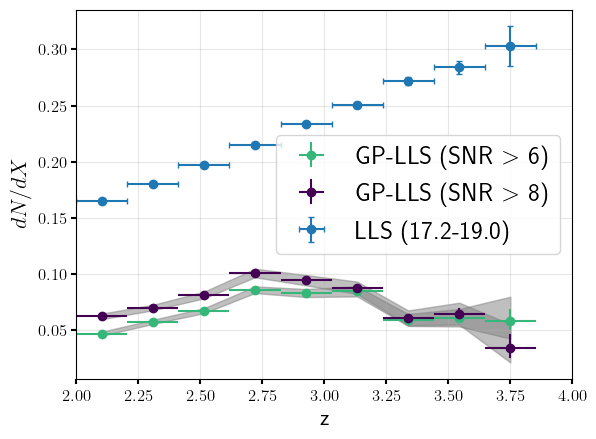

In [97]:
#  dN/dX (overlay)
fig, ax = plt.subplots()

plot_line_density(z_cent_mock, dNdX_mock, dndx68_mock, dndx95_mock, color=c_skyline, label="GP-LLS (SNR $>$ 6)", bins_per_z=5, zmin=2, zmax=4)
plot_line_density(z_cent_mock_highsnr, dNdX_mock_highsnr, dndx68_mock_highsnr, dndx95_mock_highsnr, color=c_flatirons, label="GP-LLS (SNR $>$ 8)", bins_per_z=5, zmin=2, zmax=4)

plot_dndx(out_lls, label="LLS (17.2-19.0)", prefer_boot=True, ax=ax, show=False)


<Axes: xlabel='z', ylabel='$10^{-3}\\,\\Omega_{\\rm HI}$'>

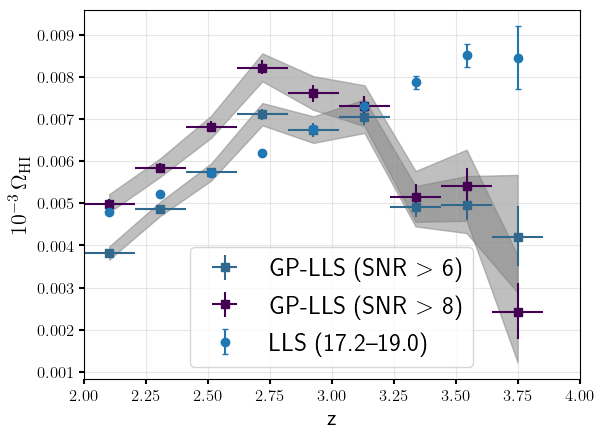

In [98]:
# OmegaHI plot
fig, ax = plt.subplots()
plot_omega_dla(
    z_cent_omega_mock,
    omega_hi_mock,
    omega68_mock,
    omega95_mock,
    color=c_midnight,
    label="GP-LLS (SNR $>$ 6)",
    bins_per_z=5,
    zmin=2,
    zmax=4,
    ylabel=r"$10^3 \times \Omega_\mathrm{LLS}$",
)
plot_omega_dla(
    z_cent_omega_mock_highsnr,
    omega_hi_mock_highsnr,
    omega68_mock_highsnr,
    omega95_mock_highsnr,
    color=c_flatirons,
    label="GP-LLS (SNR $>$ 8)",
    bins_per_z=5,
    zmin=2,
    zmax=4,
    ylabel=r"$10^3 \times \Omega_\mathrm{LLS}$",
)
plot_omega_hi(out_omega_lls, label="LLS (17.2–19.0)",  ax=ax, show=False)

* sub-DLA

<Axes: xlabel='z', ylabel='$dN/dX$'>

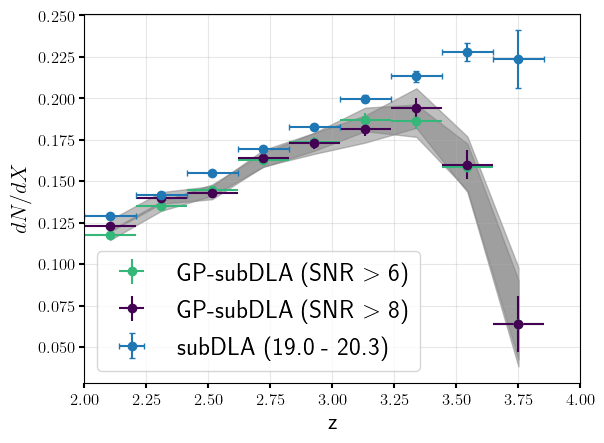

In [99]:
#  dN/dX (overlay)
fig, ax = plt.subplots()

plot_line_density(z_cent_sub_mock, dNdX_sub_mock, dndx68_sub_mock, dndx95_sub_mock, color=c_skyline, label="GP-subDLA (SNR $>$ 6)", bins_per_z=5, zmin=2, zmax=4)
plot_line_density(z_cent_sub_mock_highsnr, dNdX_sub_mock_highsnr, dndx68_sub_mock_highsnr, dndx95_sub_mock_highsnr, color=c_flatirons, label="GP-subDLA (SNR $>$ 8)", bins_per_z=5, zmin=2, zmax=4)

plot_dndx(out_subdla, label="subDLA (19.0 - 20.3)", prefer_boot=True, ax=ax, show=False)


<Axes: xlabel='z', ylabel='$10^{-3}\\,\\Omega_{\\rm HI}$'>

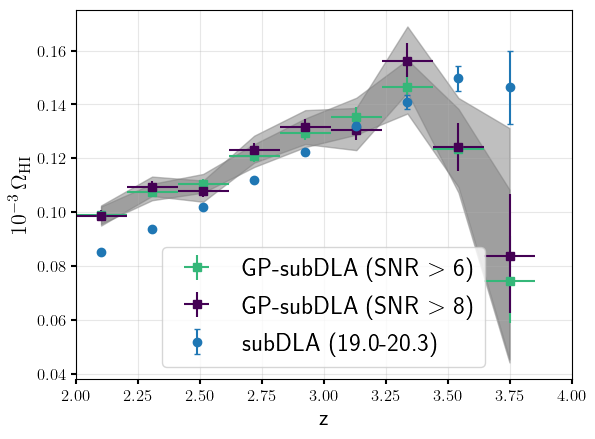

In [100]:
# OmegaHI plot
fig, ax = plt.subplots()
plot_omega_dla(
    z_cent_omega_sub_mock,
    omega_hi_sub_mock,
    omega68_sub_mock,
    omega95_sub_mock,
    color=c_skyline,
    label="GP-subDLA (SNR $>$ 6)",
    bins_per_z=5,
    zmin=2,
    zmax=4,
    ylabel=r"$10^3 \times \Omega_\mathrm{LLS}$",
)
plot_omega_dla(
    z_cent_omega_sub_mock_highsnr,
    omega_hi_sub_mock_highsnr,
    omega68_sub_mock_highsnr,
    omega95_sub_mock_highsnr,
    color=c_flatirons,
    label="GP-subDLA (SNR $>$ 8)",
    bins_per_z=5,
    zmin=2,
    zmax=4,
    ylabel=r"$10^3 \times \Omega_\mathrm{subDLA}$",
)
plot_omega_hi(out_omega_subdla, label="subDLA (19.0-20.3)",  ax=ax, show=False)

* DLA (SNR > 4)

<Axes: xlabel='z', ylabel='$dN/dX$'>

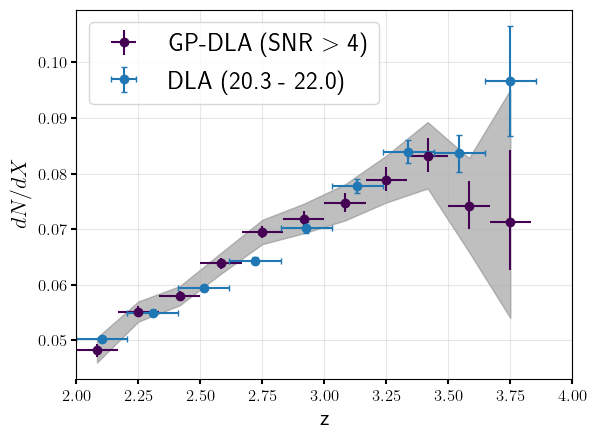

In [101]:
#  dN/dX (overlay)
fig, ax = plt.subplots()

plot_line_density(z_cent_dla_mock, dNdX_dla_mock, dndx68_dla_mock, dndx95_dla_mock, color=c_flatirons, label="GP-DLA (SNR $>$ 4)", bins_per_z=5, zmin=2, zmax=4)

plot_dndx(out_dla, label="DLA (20.3 - 22.0)", prefer_boot=True, ax=ax, show=False)


<Axes: xlabel='z', ylabel='$10^{-3}\\,\\Omega_{\\rm HI}$'>

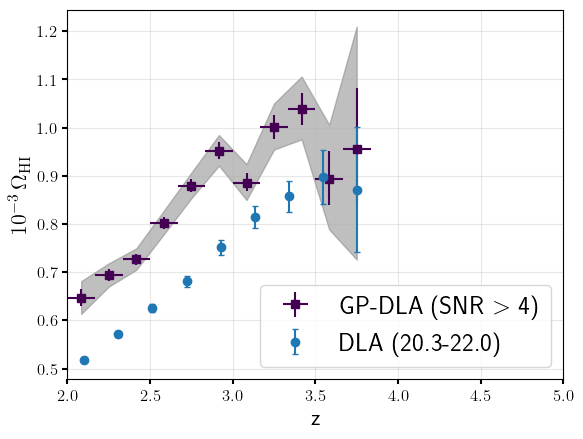

In [102]:
# OmegaHI plot
fig, ax = plt.subplots()
plot_omega_dla(
    z_cent_omega_dla_mock,
    omega_hi_dla_mock,
    omega68_dla_mock,
    omega95_dla_mock,
    color=c_flatirons,
    label="GP-DLA (SNR $>$ 4)",
    bins_per_z=5,
    zmin=2,
    zmax=5,
    ylabel=r"$10^3 \times \Omega_\mathrm{LLS}$",
)

plot_omega_hi(out_omega_dla, label="DLA (20.3-22.0)",  ax=ax, show=False)

## Calibration factor

In [103]:
import numpy as np

def sym_err_from_bounds(y, bounds68):
    """
    Convert absolute 68% bounds into a symmetric ~1σ uncertainty around y.

    y: (N,) central values
    bounds68: (N,2) absolute [low, high] bounds (NOT +/-)
    """
    y = np.asarray(y, float)
    bounds68 = np.asarray(bounds68, float)
    low = bounds68[:, 0]
    high = bounds68[:, 1]
    return 0.5 * ((y - low) + (high - y))


def _get_truth_z(out_truth):
    """Return the truth redshift grid from either 'z_mid' or 'z'."""
    if "z_mid" in out_truth:
        return np.asarray(out_truth["z_mid"], float)
    if "z" in out_truth:
        return np.asarray(out_truth["z"], float)
    raise KeyError("out_truth must contain 'z_mid' or 'z'.")


def _get_truth_y_and_err(out_truth, *, y_key, err_kind="boot"):
    """
    Get truth y and 1σ error arrays for a given y_key.

    Supported patterns:
      - dN/dX-style: y_key='dndx' with err in out_truth['err_boot'] or ['err_poisson']
      - ΩHI-style:  y_key='omega_hi' with err in out_truth['omega_hi_err']
                   (err_kind ignored unless you also store omega_hi_err_boot/poisson)
    """
    y = np.asarray(out_truth[y_key], float)

    # Most specific (if you ever store these later)
    if err_kind == "boot":
        k = f"{y_key}_err_boot"
        if k in out_truth and out_truth[k] is not None:
            return y, np.asarray(out_truth[k], float)
    else:
        k = f"{y_key}_err_poisson"
        if k in out_truth and out_truth[k] is not None:
            return y, np.asarray(out_truth[k], float)

    # dN/dX convention in your dict
    if "err_boot" in out_truth and out_truth["err_boot"] is not None and err_kind == "boot":
        return y, np.asarray(out_truth["err_boot"], float)
    if "err_poisson" in out_truth and out_truth["err_poisson"] is not None and err_kind != "boot":
        return y, np.asarray(out_truth["err_poisson"], float)

    # ΩHI convention in your dict
    if f"{y_key}_err" in out_truth and out_truth[f"{y_key}_err"] is not None:
        return y, np.asarray(out_truth[f"{y_key}_err"], float)

    # Last resort: if dN/dX requested boot but only poisson exists (or vice versa)
    if "err_boot" in out_truth and out_truth["err_boot"] is not None:
        return y, np.asarray(out_truth["err_boot"], float)
    if "err_poisson" in out_truth and out_truth["err_poisson"] is not None:
        return y, np.asarray(out_truth["err_poisson"], float)

    raise KeyError(
        f"Cannot find a truth error array for y_key='{y_key}'. "
        "Expected one of: err_boot/err_poisson, or '{y_key}_err', "
        "or '{y_key}_err_boot/poisson'."
    )


def eval_truth_at_z(z_eval, out_truth, *, y_key, err_kind="boot"):
    """
    Interpolate truth y(z) and its 1σ error onto z_eval.
    """
    zt = _get_truth_z(out_truth)
    yt, et = _get_truth_y_and_err(out_truth, y_key=y_key, err_kind=err_kind)

    z_eval = np.asarray(z_eval, float)
    yti = np.interp(z_eval, zt, yt)
    eti = np.interp(z_eval, zt, et)
    return yti, eti


def calibration_factor_alpha(
    z_meas, y_meas, bounds68_meas,
    out_truth, *,
    truth_y_key,
    truth_err_kind="boot",
    clip=None,
    eps=1e-30,
):
    """
    alpha(z) = y_true(z) / y_meas(z)

    bounds68_meas must be absolute [low, high].
    Error propagation (independent, fractional):
      (σ_alpha/alpha)^2 = (σ_true/y_true)^2 + (σ_meas/y_meas)^2
    """
    z_meas = np.asarray(z_meas, float)
    y_meas = np.asarray(y_meas, float)
    bounds68_meas = np.asarray(bounds68_meas, float)

    # measured symmetric ~1σ from bounds
    yerr_meas = sym_err_from_bounds(y_meas, bounds68_meas)

    # truth interpolated onto z_meas
    y_true, yerr_true = eval_truth_at_z(
        z_meas, out_truth, y_key=truth_y_key, err_kind=truth_err_kind
    )

    A = np.maximum(y_true, eps)
    B = np.maximum(y_meas, eps)

    alpha = A / B
    frac = np.sqrt((yerr_true / A) ** 2 + (yerr_meas / B) ** 2)
    alpha_err = alpha * frac

    if clip is not None:
        lo, hi = clip
        alpha = np.clip(alpha, lo, hi)

    # corrected series
    y_corr = y_meas * alpha
    y_corr_err = y_corr * frac

    return {
        "z": z_meas,
        "y_meas": y_meas,
        "bounds68_meas": bounds68_meas,
        "yerr_meas_sym": yerr_meas,
        "y_true": y_true,
        "yerr_true": yerr_true,
        "alpha": alpha,
        "alpha_err": alpha_err,
        "y_corr": y_corr,
        "y_corr_err": y_corr_err,
        "meta": {
            "truth_y_key": truth_y_key,
            "truth_err_kind": truth_err_kind,
        },
    }

* Lyman limit systems

In [104]:
# ------------------------------------------------------------
# Correct: dndx68_mock is [low, high] bounds, NOT error bars
# ------------------------------------------------------------

# measured ~1σ (symmetric) from absolute 68% bounds
err_meas = sym_err_from_bounds(dNdX_mock, dndx68_mock)

# calibration factor alpha(z) = truth / measured
cal_dndx = calibration_factor_alpha(
    z_meas=z_cent_mock,
    y_meas=dNdX_mock,
    bounds68_meas=dndx68_mock,   # absolute [low, high]
    out_truth=out_lls,           # truth from catalog
    truth_y_key="dndx",
    truth_err_kind="boot",
    clip=None,
)

######### SNR > 8 #########
err_meas_highsnr = sym_err_from_bounds(dNdX_mock_highsnr, dndx68_mock_highsnr)

cal_highsnr = calibration_factor_alpha(
    z_meas=z_cent_mock_highsnr,
    y_meas=dNdX_mock_highsnr,
    bounds68_meas=dndx68_mock_highsnr,   # <-- bounds [low, high]
    out_truth=out_lls,           # truth from catalog
    truth_y_key="dndx",
    truth_err_kind="boot",       # or "poisson"
    clip=None
)

# If you specifically still want err_meas as an array for quick inspection:
# err_meas = cal["yerr_meas_sym"]

########### Omega_HI plot############

# omega_HI correction
cal_omega = calibration_factor_alpha(
    z_meas=z_cent_omega_mock,
    y_meas=omega_hi_mock * 1e-3,   # scale to match plot_omega_hi y-axis
    bounds68_meas=omega68_mock,     # absolute [low, high] for ΩHI measurement
    out_truth=out_omega_lls,      # dict with z/omega_hi/omega_hi_err
    truth_y_key="omega_hi",
    truth_err_kind="boot",          # ignored here unless you later add omega_hi_err_boot
)

######### SNR > 8 #########
cal_omega_highsnr = calibration_factor_alpha(
    z_meas=z_cent_omega_mock_highsnr,
    y_meas=omega_hi_mock_highsnr * 1e-3,   # scale to match plot_omega_hi y-axis
    bounds68_meas=omega68_mock_highsnr,     # absolute [low, high] for ΩHI measurement
    out_truth=out_omega_lls,      # dict with z/omega_hi/omega_hi_err
    truth_y_key="omega_hi",
    truth_err_kind="boot",          # ignored here unless you later add omega_hi_err_boot
)

* subDLA

In [105]:
## SUBDLA ##
# ------------------------------------------------------------
# Correct: dndx68_mock is [low, high] bounds, NOT error bars
# ------------------------------------------------------------

# calibration factor alpha(z) = truth / measured
cal_dndx_sub = calibration_factor_alpha(
    z_meas=z_cent_sub_mock,
    y_meas=dNdX_sub_mock,
    bounds68_meas=dndx68_sub_mock,   # absolute [low, high]
    out_truth=out_subdla,      # truth from catalog
    truth_y_key="dndx",
    truth_err_kind="boot",
    clip=None,
)

######### SNR > 8 #########
cal_highsnr_sub = calibration_factor_alpha(
    z_meas=z_cent_sub_mock_highsnr,
    y_meas=dNdX_sub_mock_highsnr,
    bounds68_meas=dndx68_sub_mock_highsnr,   # <-- bounds [low, high]
    out_truth=out_subdla,           # truth from catalog
    truth_y_key="dndx",
    truth_err_kind="boot",       # or "poisson"
    clip=None
)

########### Omega_HI plot############

# omega_HI correction
cal_omega_sub = calibration_factor_alpha(
    z_meas=z_cent_omega_sub_mock,
    y_meas=omega_hi_sub_mock * 1e-3,   # scale to match plot_omega_hi y-axis
    bounds68_meas=omega68_sub_mock,     # absolute [low, high] for ΩHI measurement
    out_truth=out_omega_subdla,      # dict with z/omega_hi/omega_hi_err
    truth_y_key="omega_hi",
    truth_err_kind="boot",          # ignored here unless you later add omega_hi_err_boot
)

######### SNR > 8 #########
cal_omega_highsnr_sub = calibration_factor_alpha(
    z_meas=z_cent_omega_sub_mock_highsnr,
    y_meas=omega_hi_sub_mock_highsnr * 1e-3,   # scale to match plot_omega_hi y-axis
    bounds68_meas=omega68_sub_mock_highsnr,     # absolute [low, high] for ΩHI measurement
    out_truth=out_omega_subdla,      # dict with z/omega_hi/omega_hi_err
    truth_y_key="omega_hi",
    truth_err_kind="boot",          # ignored here unless you later add omega_hi_err_boot
)

* DLA

In [106]:
## DLA ##
# ------------------------------------------------------------
# Correct: dndx68_mock is [low, high] bounds, NOT error bars
# ------------------------------------------------------------

# calibration factor alpha(z) = truth / measured
cal_dndx_dla = calibration_factor_alpha(
    z_meas=z_cent_dla_mock,
    y_meas=dNdX_dla_mock,
    bounds68_meas=dndx68_dla_mock,   # absolute [low, high]
    out_truth=out_dla,      # truth from catalog
    truth_y_key="dndx",
    truth_err_kind="boot",
    clip=None,
)

########### Omega_HI plot############

# omega_HI correction
cal_omega_dla = calibration_factor_alpha(
    z_meas=z_cent_omega_dla_mock,
    y_meas=omega_hi_dla_mock * 1e-3,   # scale to match plot_omega_hi y-axis
    bounds68_meas=omega68_dla_mock,     # absolute [low, high] for ΩHI measurement
    out_truth=out_omega_dla,      # dict with z/omega_hi/omega_hi_err
    truth_y_key="omega_hi",
    truth_err_kind="boot",          # ignored here unless you later add omega_hi_err_boot
)

#### Mock validation plot: alpha(z)

* LLS

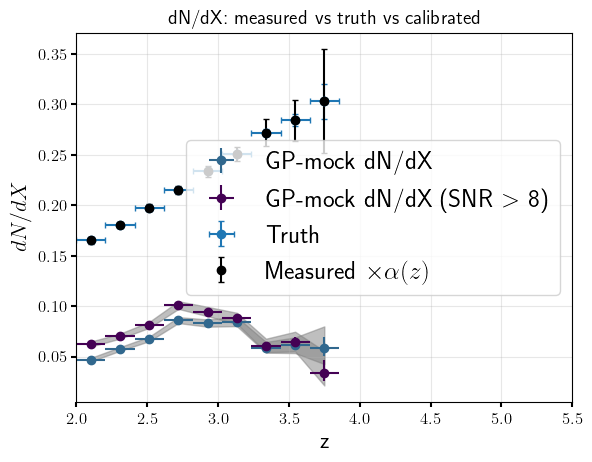

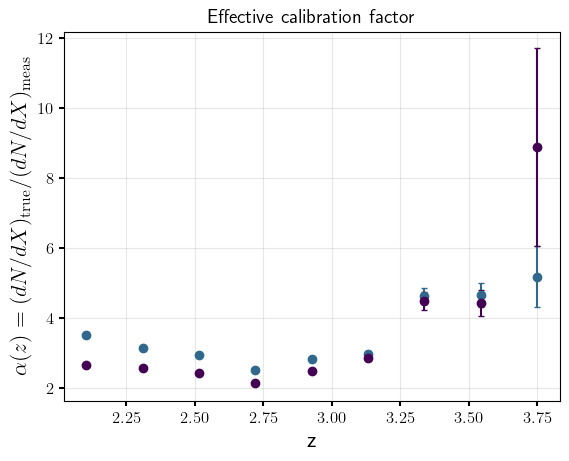

In [107]:
import matplotlib.pyplot as plt

# --- (A) overlay curves ---
fig, ax = plt.subplots()

# your measured curve (blue) — you already have plot_line_density
plot_line_density(
    z_cent_mock, dNdX_mock, dndx68_mock, dndx95_mock,
    color=c_midnight, label="GP-mock dN/dX"
)
# SNR > 8
plot_line_density(
    z_cent_mock_highsnr, dNdX_mock_highsnr, dndx68_mock_highsnr, dndx95_mock_highsnr,
    color=c_flatirons, label="GP-mock dN/dX (SNR $>$ 8)"
)

# truth (from catalog)
plot_dndx(out_lls, label="Truth", prefer_boot=True, ax=ax, show=False)

# (3) Calibrated curve (measured × alpha)
# This has a *derived* symmetric uncertainty, so errorbar is appropriate
ax.errorbar(
    cal_dndx["z"],
    cal_dndx["y_corr"],
    yerr=cal_dndx["y_corr_err"],
    fmt="o",
    color="black",
    capsize=2,
    label=r"Measured $\times \alpha(z)$",
)

ax.set_title("dN/dX: measured vs truth vs calibrated")
ax.legend()
plt.show()


# --- (B) calibration factor alpha(z) ---
fig, ax = plt.subplots()

ax.errorbar(
    cal_dndx["z"],
    cal_dndx["alpha"],
    yerr=cal_dndx["alpha_err"],
    fmt="o",
    capsize=2,
    color=c_midnight,
)

# snr > 8
ax.errorbar(
    cal_highsnr["z"],
    cal_highsnr["alpha"],
    yerr=cal_highsnr["alpha_err"],
    fmt="o",
    capsize=2,
    color=c_flatirons,
)

ax.set_xlabel("z")
ax.set_ylabel(r"$\alpha(z) = (dN/dX)_{\rm true} / (dN/dX)_{\rm meas}$")
ax.set_title("Effective calibration factor")
ax.grid(True, alpha=0.3)

plt.show()

* subDLA

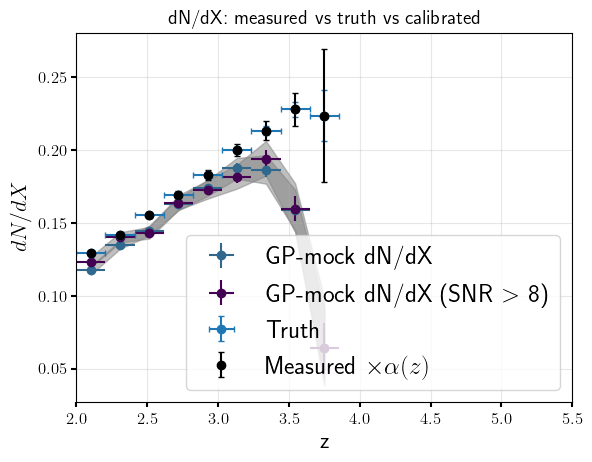

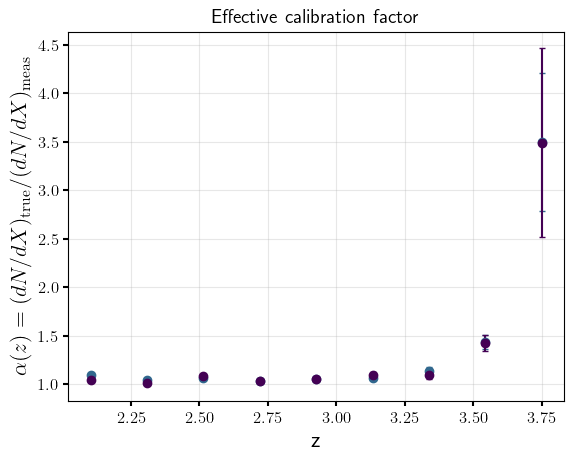

In [108]:
### SUBDLA PLOTS ###
import matplotlib.pyplot as plt

# --- (A) overlay curves ---
fig, ax = plt.subplots()

# your measured curve (blue) — you already have plot_line_density
plot_line_density(
    z_cent_sub_mock, dNdX_sub_mock, dndx68_sub_mock, dndx95_sub_mock,
    color=c_midnight, label="GP-mock dN/dX"
)
# SNR > 8
plot_line_density(
    z_cent_sub_mock_highsnr, dNdX_sub_mock_highsnr, dndx68_sub_mock_highsnr, dndx95_sub_mock_highsnr,
    color=c_flatirons, label="GP-mock dN/dX (SNR $>$ 8)"
)

# truth (from catalog)
plot_dndx(out_subdla, label="Truth", prefer_boot=True, ax=ax, show=False)

# (3) Calibrated curve (measured × alpha)
# This has a *derived* symmetric uncertainty, so errorbar is appropriate
ax.errorbar(
    cal_dndx_sub["z"],
    cal_dndx_sub["y_corr"],
    yerr=cal_dndx_sub["y_corr_err"],
    fmt="o",
    color="black",
    capsize=2,
    label=r"Measured $\times \alpha(z)$",
)

ax.set_title("dN/dX: measured vs truth vs calibrated")
ax.legend()
plt.show()


# --- (B) calibration factor alpha(z) ---
fig, ax = plt.subplots()

ax.errorbar(
    cal_dndx_sub["z"],
    cal_dndx_sub["alpha"],
    yerr=cal_dndx_sub["alpha_err"],
    fmt="o",
    capsize=2,
    color=c_midnight,
)

# snr > 8
ax.errorbar(
    cal_highsnr_sub["z"],
    cal_highsnr_sub["alpha"],
    yerr=cal_highsnr_sub["alpha_err"],
    fmt="o",
    capsize=2,
    color=c_flatirons,
)

ax.set_xlabel("z")
ax.set_ylabel(r"$\alpha(z) = (dN/dX)_{\rm true} / (dN/dX)_{\rm meas}$")
ax.set_title("Effective calibration factor")
ax.grid(True, alpha=0.3)

plt.show()

* DLA

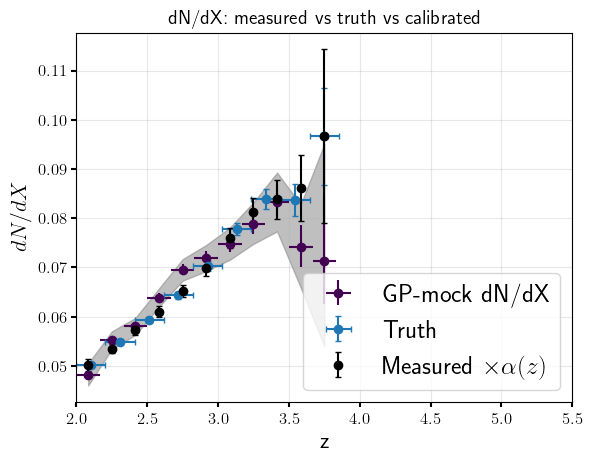

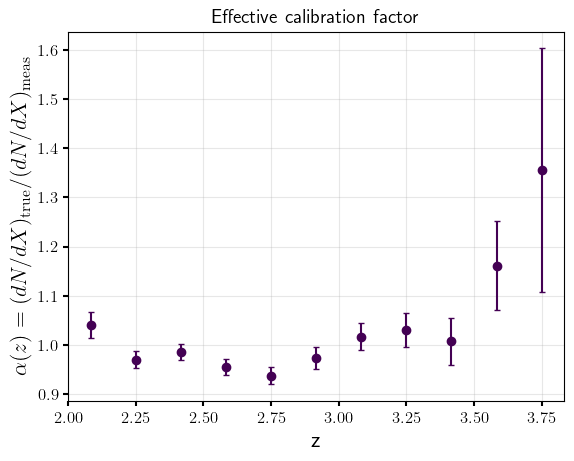

In [109]:
### DLA PLOTS ###
import matplotlib.pyplot as plt

# --- (A) overlay curves ---
fig, ax = plt.subplots()

# your measured curve (blue) — you already have plot_line_density
plot_line_density(
    z_cent_dla_mock, dNdX_dla_mock, dndx68_dla_mock, dndx95_dla_mock,
    color=c_flatirons, label="GP-mock dN/dX"
)

# truth (from catalog)
plot_dndx(out_dla, label="Truth", prefer_boot=True, ax=ax, show=False)

# (3) Calibrated curve (measured × alpha)
# This has a *derived* symmetric uncertainty, so errorbar is appropriate
ax.errorbar(
    cal_dndx_dla["z"],
    cal_dndx_dla["y_corr"],
    yerr=cal_dndx_dla["y_corr_err"],
    fmt="o",
    color="black",
    capsize=2,
    label=r"Measured $\times \alpha(z)$",
)

ax.set_title("dN/dX: measured vs truth vs calibrated")
ax.legend()
plt.show()


# --- (B) calibration factor alpha(z) ---
fig, ax = plt.subplots()

ax.errorbar(
    cal_dndx_dla["z"],
    cal_dndx_dla["alpha"],
    yerr=cal_dndx_dla["alpha_err"],
    fmt="o",
    capsize=2,
    color=c_flatirons,
)

ax.set_xlabel("z")
ax.set_ylabel(r"$\alpha(z) = (dN/dX)_{\rm true} / (dN/dX)_{\rm meas}$")
ax.set_title("Effective calibration factor")
ax.grid(True, alpha=0.3)

plt.show()

## Calibrated measurement: Loa catalog


In [110]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Apply mock-derived calibration factor alpha(z) to REAL dN/dX and ΩHI
# Assumes:
#   cal["z"], cal["alpha"], cal["alpha_err"] already computed from mocks
#   dndx68/dndx95 (and omega68/omega95 if available) are absolute bounds [low, high]
# ============================================================

def bounds_to_asym_sigma(y, low, high):
    """
    Convert absolute bounds [low, high] around y into asymmetric sigmas:
      sigma_minus = y - low
      sigma_plus  = high - y
    """
    y = np.asarray(y, float)
    low = np.asarray(low, float)
    high = np.asarray(high, float)
    return (y - low, high - y)


def _interp_alpha_at_z(z_cent, cal, *, clip_alpha=None):
    """
    Interpolate alpha(z) and alpha_err(z) from a calibration dict 'cal' onto z_cent.
    """
    z_cent = np.asarray(z_cent, float)

    z_cal = np.asarray(cal["z"], float)
    alpha_cal = np.asarray(cal["alpha"], float)
    alpha_err_cal = np.asarray(cal["alpha_err"], float)

    alpha = np.interp(z_cent, z_cal, alpha_cal)
    alpha_err = np.interp(z_cent, z_cal, alpha_err_cal)

    if clip_alpha is not None:
        lo, hi = clip_alpha
        alpha = np.clip(alpha, lo, hi)

    return alpha, alpha_err


def apply_alpha_to_bounds(
    z_cent, y, y68_low, y68_high, y95_low, y95_high,
    cal, *,
    include_alpha_uncertainty=True,
    clip_alpha=None,
):
    """
    Generic helper: apply y_corr = alpha(z) * y to any measurement storing
    absolute bounds at 68% and 95% [low, high].

    Propagate uncertainties (independent) with asymmetric lower/upper separately:
      frac_minus^2 = (sigma_minus/y)^2 + (sigma_alpha/alpha)^2
      frac_plus^2  = (sigma_plus /y)^2 + (sigma_alpha/alpha)^2
    """
    z_cent = np.asarray(z_cent, float)
    y = np.asarray(y, float)

    y68_low = np.asarray(y68_low, float)
    y68_high = np.asarray(y68_high, float)
    y95_low = np.asarray(y95_low, float)
    y95_high = np.asarray(y95_high, float)

    alpha, alpha_err = _interp_alpha_at_z(z_cent, cal, clip_alpha=clip_alpha)
    y_corr = alpha * y

    # bounds -> asymmetric sigmas
    sig68_m, sig68_p = bounds_to_asym_sigma(y, y68_low, y68_high)
    sig95_m, sig95_p = bounds_to_asym_sigma(y, y95_low, y95_high)

    eps = 1e-30
    frac_alpha = alpha_err / np.maximum(alpha, eps) if include_alpha_uncertainty else 0.0

    frac68_m = sig68_m / np.maximum(y, eps)
    frac68_p = sig68_p / np.maximum(y, eps)
    frac95_m = sig95_m / np.maximum(y, eps)
    frac95_p = sig95_p / np.maximum(y, eps)

    sig68_m_corr = y_corr * np.sqrt(frac68_m**2 + frac_alpha**2)
    sig68_p_corr = y_corr * np.sqrt(frac68_p**2 + frac_alpha**2)
    sig95_m_corr = y_corr * np.sqrt(frac95_m**2 + frac_alpha**2)
    sig95_p_corr = y_corr * np.sqrt(frac95_p**2 + frac_alpha**2)

    y68_low_corr = y_corr - sig68_m_corr
    y68_high_corr = y_corr + sig68_p_corr
    y95_low_corr = y_corr - sig95_m_corr
    y95_high_corr = y_corr + sig95_p_corr

    return {
        "z_cent": z_cent,
        "alpha": alpha,
        "alpha_err": alpha_err,
        "y_raw": y,
        "y_corr": y_corr,
        "y68_low_corr": y68_low_corr,
        "y68_high_corr": y68_high_corr,
        "y95_low_corr": y95_low_corr,
        "y95_high_corr": y95_high_corr,
    }


def apply_alpha_to_dndx_bounds(
    z_cent, y, y68_low, y68_high, y95_low, y95_high,
    cal, *,
    include_alpha_uncertainty=True,
    clip_alpha=None,
):
    """
    Backward-compatible wrapper for dN/dX.
    """
    return apply_alpha_to_bounds(
        z_cent, y, y68_low, y68_high, y95_low, y95_high,
        cal,
        include_alpha_uncertainty=include_alpha_uncertainty,
        clip_alpha=clip_alpha,
    )


def apply_alpha_to_omegahi_real(
    z_cent, omega, omega68_low, omega68_high, omega95_low, omega95_high,
    cal_omega, *,
    include_alpha_uncertainty=True,
    clip_alpha=None,
):
    """
    Apply mock-derived ΩHI calibration factor alpha_Ω(z) to REAL ΩHI measurement.

    Inputs are ΩHI central + absolute bounds:
      omega68_low/high, omega95_low/high are absolute bounds [low, high].

    Uses the same multiplicative correction:
      Ω_corr(z) = alpha_Ω(z) * Ω_meas(z)

    and the same asymmetric fractional propagation as dN/dX.
    """
    return apply_alpha_to_bounds(
        z_cent, omega, omega68_low, omega68_high, omega95_low, omega95_high,
        cal_omega,
        include_alpha_uncertainty=include_alpha_uncertainty,
        clip_alpha=clip_alpha,
    )


# ----------------------------
# Optional: plotting helper (×1000)
# ----------------------------

def plot_omega_hi_scaled(out_omega, *, ax=None, label=None, show=True, scale=1e3):
    """
    Plot (scale * ΩHI) with errors scaled by the same factor.
    """
    z = np.asarray(out_omega["z_cent"], float) if "z_cent" in out_omega else np.asarray(out_omega["z"], float)

    # allow either keys from apply_alpha_* output or your omega dict
    if "omega_hi" in out_omega:
        y = np.asarray(out_omega["omega_hi"], float)
        yerr = np.asarray(out_omega["omega_hi_err"], float)
        y68_low = y - yerr
        y68_high = y + yerr
    else:
        y = np.asarray(out_omega["y_corr"], float) if "y_corr" in out_omega else np.asarray(out_omega["y_raw"], float)
        # use 68% corrected bounds if present, else fall back
        y68_low = np.asarray(out_omega.get("y68_low_corr", np.nan*np.ones_like(y)), float)
        y68_high = np.asarray(out_omega.get("y68_high_corr", np.nan*np.ones_like(y)), float)

    y_s = scale * y
    y68_low_s = scale * y68_low
    y68_high_s = scale * y68_high
    yerr_m = y_s - y68_low_s
    yerr_p = y68_high_s - y_s

    if ax is None:
        fig, ax = plt.subplots()

    ax.errorbar(z, y_s, yerr=[yerr_m, yerr_p], fmt="o", capsize=2, label=label)
    ax.set_xlabel("z")
    ax.set_ylabel(rf"${scale:.0e}\times \Omega_{{\rm HI}}$")
    ax.grid(True, alpha=0.3)
    if label:
        ax.legend()
    if show:
        plt.show()
    return ax

* LLS

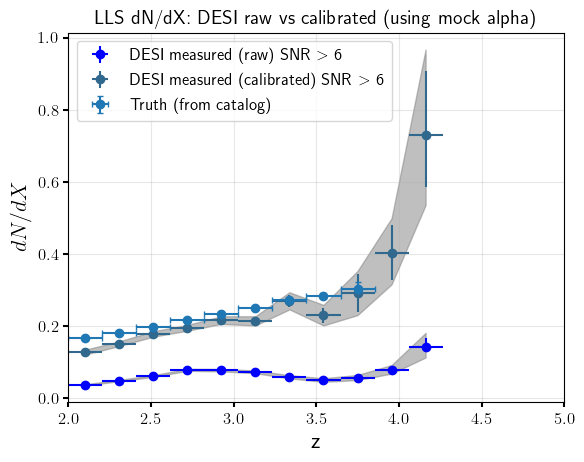

In [111]:
# ------------------------------------------------------------
# 1) Load REAL measurement from file
# ------------------------------------------------------------

subdir = "/Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/cddf_all/dla_cddf_20260107/desi_snr6.0_zqsos_2.15-5.0_dla_5.5_occam_1.0_dla_model_1_zminlyb_22.0_minobswave_3700.0_bins_5_lnhi_17.2-22.0_lnhi_dndx_17.2-19.0/"

# dN/dX: Fiducial
dndx_all = np.loadtxt(os.path.join(subdir, "dndx_all.txt"))
(_, N) = dndx_all.shape

dndx68 = np.full((N, 2), fill_value=np.nan)
dndx95 = np.full((N, 2), fill_value=np.nan)
(
    z_cent,
    dNdX,
    dndx68[:, 0],
    dndx68[:, 1],
    dndx95[:, 0],
    dndx95[:, 1],
) = dndx_all

# # ------------- SNR > 8 -------------
# subdir = "/Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/cddf_all/dla_cddf_20260107/desi_snr8.0_zqsos_2.15-5.0_dla_5.5_occam_1.0_dla_model_1_zminlyb_22.0_minobswave_3700.0_bins_5_lnhi_17.2-22.0_lnhi_dndx_17.2-19.0_z_dla_cddf_min_1.0_z_dla_dndx_min_2.0/"

# # dN/dX: Fiducial
# dndx_all = np.loadtxt(os.path.join(subdir, "dndx_all.txt"))
# (_, N) = dndx_all.shape

# dndx68_highsnr = np.full((N, 2), fill_value=np.nan)
# dndx95_highsnr = np.full((N, 2), fill_value=np.nan)
# (
#     z_cent_highsnr,
#     dNdX_highsnr,
#     dndx68_highsnr[:, 0],
#     dndx68_highsnr[:, 1],
#     dndx95_highsnr[:, 0],
#     dndx95_highsnr[:, 1],
# ) = dndx_all


# plot_line_density(z_cent, dNdX, dndx68, dndx95, color="blue", label="GP-LLS (SNR > 6)", bins_per_z=5, zmin=2, zmax=4.25)

# ------------------------------------------------------------
# 2) Apply calibration alpha(z) from mocks to REAL measurement
# ------------------------------------------------------------
# cal must already exist from your mock calibration step
corr_real = apply_alpha_to_dndx_bounds(
    z_cent=z_cent,
    y=dNdX,
    y68_low=dndx68[:, 0], y68_high=dndx68[:, 1],
    y95_low=dndx95[:, 0], y95_high=dndx95[:, 1],
    cal=cal_dndx,
    include_alpha_uncertainty=True,
    clip_alpha=None,
)

dndx68_corr = np.column_stack([corr_real["y68_low_corr"], corr_real["y68_high_corr"]])
dndx95_corr = np.column_stack([corr_real["y95_low_corr"], corr_real["y95_high_corr"]])

# # ----------- SNR > 8 -----------
# corr_real_highsnr = apply_alpha_to_dndx_bounds(
#     z_cent=z_cent_highsnr,
#     y=dNdX_highsnr,
#     y68_low=dndx68_highsnr[:, 0], y68_high=dndx68_highsnr[:, 1],
#     y95_low=dndx95_highsnr[:, 0], y95_high=dndx95_highsnr[:, 1],
#     cal=cal_highsnr,
#     include_alpha_uncertainty=True,
#     clip_alpha=None,
# )

# dndx68_corr_highsnr = np.column_stack([corr_real_highsnr["y68_low_corr"], corr_real_highsnr["y68_high_corr"]])
# dndx95_corr_highsnr = np.column_stack([corr_real_highsnr["y95_low_corr"], corr_real_highsnr["y95_high_corr"]])

# ------------------------------------------------------------
# 3) Plot: raw vs calibrated (bounds-style)
# ------------------------------------------------------------
fig, ax = plt.subplots()

plot_line_density(
    z_cent, dNdX, dndx68, dndx95,
    color="blue", label="DESI measured (raw) SNR $>$ 6",
    zmin=2, zmax=5,
    use_zcent_for_xerr=True,
)

plot_line_density(
    corr_real["z_cent"], corr_real["y_corr"], dndx68_corr, dndx95_corr,
    color=c_midnight, label="DESI measured (calibrated) SNR $>$ 6",
    zmin=2, zmax=5,
    use_zcent_for_xerr=True,
)

# plot_line_density(
#     corr_real_highsnr["z_cent"], corr_real_highsnr["y_corr"], dndx68_corr_highsnr, dndx95_corr_highsnr,
#     color=c_flatirons, label="DESI measured (calibrated) SNR $>$ 8",
#     zmin=2, zmax=5,
#     use_zcent_for_xerr=True,
# )

ax.set_xlabel("z")
ax.set_ylabel(r"$dN/dX$")
ax.set_title("LLS dN/dX: DESI raw vs calibrated (using mock alpha)")
ax.legend()
ax.grid(True, alpha=0.3)
# plt.show()

# # ------------------------------------------------------------
# # 4) Save calibrated file (same column format)
# # ------------------------------------------------------------
# out_arr = np.column_stack([
#     corr_real["z_cent"],
#     corr_real["y_corr"],
#     dndx68_corr[:, 0], dndx68_corr[:, 1],
#     dndx95_corr[:, 0], dndx95_corr[:, 1],
# ])

# np.savetxt(
#     os.path.join(subdir, "dndx_all_calibrated.txt"),
#     out_arr,
#     header="z_cent  dNdX_cal  dndx68_low  dndx68_high  dndx95_low  dndx95_high"
# )

# truth (from catalog)
plot_dndx(out_lls, label="Truth (from catalog)", prefer_boot=True, ax=ax, show=False)

plt.legend(fontsize=12)

* subDLA

<Axes: title={'center': 'subDLA: DESI raw vs calibrated (using mock alpha)'}, xlabel='z', ylabel='$1e+03\\times \\Omega_{\\rm HI}$'>

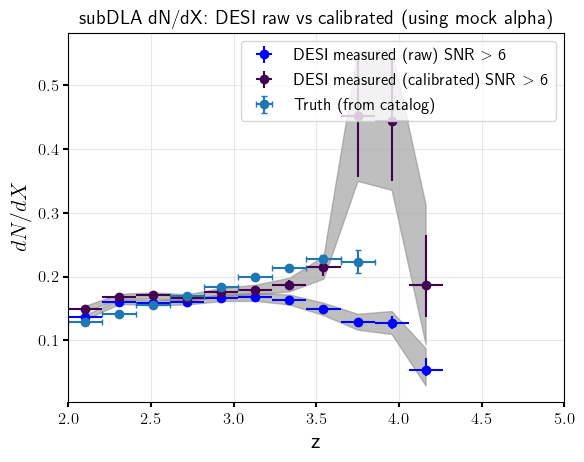

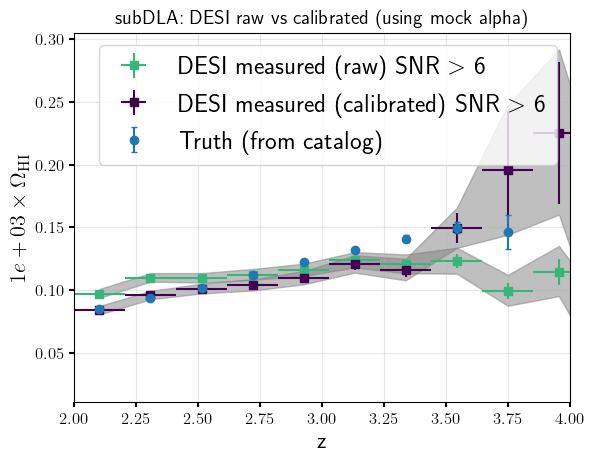

In [112]:
### SUBDLA ###
# ------------------------------------------------------------
# 1) Load REAL measurement from file
# ------------------------------------------------------------

subdir = "/Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/cddf_all/dla_cddf_20260107/desi_snr6.0_zqsos_2.15-5.0_dla_5.5_occam_1.0_dla_model_1_zminlyb_22.0_minobswave_3700.0_bins_5_lnhi_17.2-22.0_lnhi_dndx_19.0-20.3/"

# dN/dX: Fiducial
dndx_all = np.loadtxt(os.path.join(subdir, "dndx_all.txt"))
(_, N) = dndx_all.shape

dndx68_sub = np.full((N, 2), fill_value=np.nan)
dndx95_sub = np.full((N, 2), fill_value=np.nan)
(
    z_cent_sub,
    dNdX_sub,
    dndx68_sub[:, 0],
    dndx68_sub[:, 1],
    dndx95_sub[:, 0],
    dndx95_sub[:, 1],
) = dndx_all

# OmegaHI
omega_all = np.loadtxt(os.path.join(subdir, "omega_dla_all.txt"))
omega68_sub = np.full((N, 2), fill_value=np.nan)
omega95_sub = np.full((N, 2), fill_value=np.nan)
(
    z_cent_omega_sub,
    omega_hi_sub,
    omega68_sub[:, 0],
    omega68_sub[:, 1],
    omega95_sub[:, 0],
    omega95_sub[:, 1],
) = omega_all

# ------------------------------------------------------------
# 2) Apply calibration alpha(z) from mocks to REAL measurement
# ------------------------------------------------------------
# cal must already exist from your mock calibration step
corr_real_sub = apply_alpha_to_dndx_bounds(
    z_cent=z_cent_sub,
    y=dNdX_sub,
    y68_low=dndx68_sub[:, 0], y68_high=dndx68_sub[:, 1],
    y95_low=dndx95_sub[:, 0], y95_high=dndx95_sub[:, 1],
    cal=cal_dndx_sub,
    include_alpha_uncertainty=True,
    clip_alpha=None,
)

dndx68_corr_sub = np.column_stack([corr_real_sub["y68_low_corr"], corr_real_sub["y68_high_corr"]])
dndx95_corr_sub = np.column_stack([corr_real_sub["y95_low_corr"], corr_real_sub["y95_high_corr"]])

# OmegaHI
corr_omega_sub = apply_alpha_to_omegahi_real(
    z_cent=z_cent_omega_sub,
    omega=omega_hi_sub * 1e-3,  # scale to match plot_omega_hi y-axis
    omega68_low=omega68_sub[:, 0], omega68_high=omega68_sub[:, 1],
    omega95_low=omega95_sub[:, 0], omega95_high=omega95_sub[:, 1],
    cal_omega=cal_omega_sub,
    include_alpha_uncertainty=True,
    clip_alpha=None,
)

omega68_corr_sub = np.column_stack([corr_omega_sub["y68_low_corr"], corr_omega_sub["y68_high_corr"]])
omega95_corr_sub = np.column_stack([corr_omega_sub["y95_low_corr"], corr_omega_sub["y95_high_corr"]])

# ------------------------------------------------------------
# 3) Plot: raw vs calibrated (bounds-style)
# ------------------------------------------------------------
fig, ax = plt.subplots()

plot_line_density(
    z_cent_sub, dNdX_sub, dndx68_sub, dndx95_sub,
    color="blue", label="DESI measured (raw) SNR $>$ 6",
    zmin=2, zmax=5,
    use_zcent_for_xerr=True,
)

plot_line_density(
    corr_real_sub["z_cent"], corr_real_sub["y_corr"], dndx68_corr_sub, dndx95_corr_sub,
    color=c_flatirons, label="DESI measured (calibrated) SNR $>$ 6",
    zmin=2, zmax=5,
    use_zcent_for_xerr=True,
)

ax.set_xlabel("z")
ax.set_ylabel(r"$dN/dX$")
ax.set_title("subDLA dN/dX: DESI raw vs calibrated (using mock alpha)")
ax.legend()
ax.grid(True, alpha=0.3)
# plt.show()

# # ------------------------------------------------------------
# # 4) Save calibrated file (same column format)
# # ------------------------------------------------------------
# out_arr = np.column_stack([
#     corr_real["z_cent"],
#     corr_real["y_corr"],
#     dndx68_corr[:, 0], dndx68_corr[:, 1],
#     dndx95_corr[:, 0], dndx95_corr[:, 1],
# ])

# np.savetxt(
#     os.path.join(subdir, "dndx_all_calibrated.txt"),
#     out_arr,
#     header="z_cent  dNdX_cal  dndx68_low  dndx68_high  dndx95_low  dndx95_high"
# )

# truth (from catalog)
plot_dndx(out_subdla, label="Truth (from catalog)", prefer_boot=True, ax=ax, show=False)

plt.legend(fontsize=12)


############# Plot OmegaHI #############
fig, ax = plt.subplots()
plot_omega_dla(
    z_cent_omega_sub,
    omega_hi_sub,
    omega68_sub,
    omega95_sub,
    color=c_skyline,
    label="DESI measured (raw) SNR $>$ 6",
    bins_per_z=5,
    zmin=2,
    zmax=4,
    ylabel=r"$10^3 \times \Omega_\mathrm{HI}$",
)
plot_omega_dla(
    corr_omega_sub["z_cent"],
    corr_omega_sub["y_corr"] * 1e3,  # scale to match plot_omega_hi y-axis
    omega68_corr_sub,
    omega95_corr_sub,
    color=c_flatirons,
    label="DESI measured (calibrated) SNR $>$ 6",
    bins_per_z=5,
    zmin=2,
    zmax=4,
    ylabel=r"$10^3 \times \Omega_\mathrm{HI}$",
)

ax.set_title("subDLA: DESI raw vs calibrated (using mock alpha)")
# truth (from catalog)
plot_omega_hi_scaled(
    out_omega_subdla,
    ax=ax,
    label="Truth (from catalog)",
    scale=1e3,
    show=False,
)

* DLA

(0.0, 2.0)

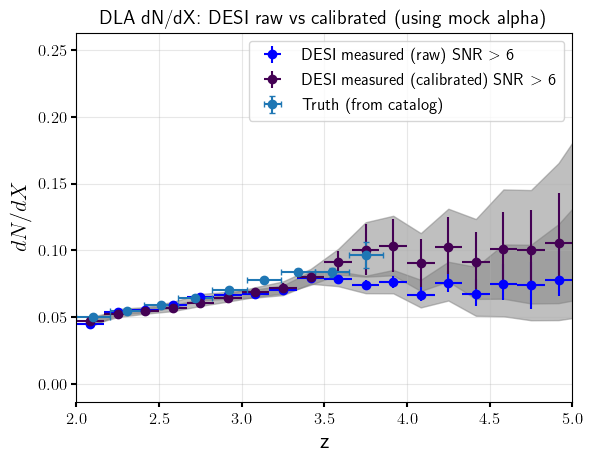

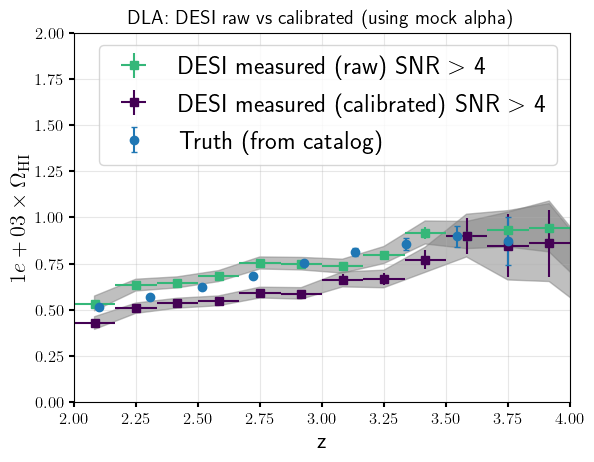

In [116]:
### DLA ###
# ------------------------------------------------------------
# 1) Load REAL measurement from file
# ------------------------------------------------------------

subdir = "/Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/dla_cddf/dla_cddf_20250302/desi_snr4.0_zqsos_2.5-6.0_dla_5.5_occam_1.0_dla_model_3_subdla_zminlyb_highnhi_21.5_minobswave_3700.0_bins_6/"

# dN/dX: Fiducial
dndx_all = np.loadtxt(os.path.join(subdir, "dndx_all.txt"))
(_, N) = dndx_all.shape

dndx68_dla = np.full((N, 2), fill_value=np.nan)
dndx95_dla = np.full((N, 2), fill_value=np.nan)
(
    z_cent_dla,
    dNdX_dla,
    dndx68_dla[:, 0],
    dndx68_dla[:, 1],
    dndx95_dla[:, 0],
    dndx95_dla[:, 1],
) = dndx_all

# OmegaHI
omega_all = np.loadtxt(os.path.join(subdir, "omega_dla_all.txt"))
omega68_dla = np.full((N, 2), fill_value=np.nan)
omega95_dla = np.full((N, 2), fill_value=np.nan)
(
    z_cent_omega_dla,
    omega_hi_dla,
    omega68_dla[:, 0],
    omega68_dla[:, 1],
    omega95_dla[:, 0],
    omega95_dla[:, 1],
) = omega_all

# ------------------------------------------------------------
# 2) Apply calibration alpha(z) from mocks to REAL measurement
# ------------------------------------------------------------
# cal must already exist from your mock calibration step
corr_real_dla = apply_alpha_to_dndx_bounds(
    z_cent=z_cent_dla,
    y=dNdX_dla,
    y68_low=dndx68_dla[:, 0], y68_high=dndx68_dla[:, 1],
    y95_low=dndx95_dla[:, 0], y95_high=dndx95_dla[:, 1],
    cal=cal_dndx_dla,
    include_alpha_uncertainty=True,
    clip_alpha=None,
)

dndx68_corr_dla = np.column_stack([corr_real_dla["y68_low_corr"], corr_real_dla["y68_high_corr"]])
dndx95_corr_dla = np.column_stack([corr_real_dla["y95_low_corr"], corr_real_dla["y95_high_corr"]])

# OmegaHI
corr_omega_dla = apply_alpha_to_omegahi_real(
    z_cent=z_cent_omega_dla,
    omega=omega_hi_dla * 1e-3,  # scale to match plot_omega_hi y-axis
    omega68_low=omega68_dla[:, 0], omega68_high=omega68_dla[:, 1],
    omega95_low=omega95_dla[:, 0], omega95_high=omega95_dla[:, 1],
    cal_omega=cal_omega_dla,
    include_alpha_uncertainty=True,
    clip_alpha=None,
)

omega68_corr_dla = np.column_stack([corr_omega_dla["y68_low_corr"], corr_omega_dla["y68_high_corr"]])
omega95_corr_dla = np.column_stack([corr_omega_dla["y95_low_corr"], corr_omega_dla["y95_high_corr"]])

# ------------------------------------------------------------
# 3) Plot: raw vs calibrated (bounds-style)
# ------------------------------------------------------------
fig, ax = plt.subplots()

plot_line_density(
    z_cent_dla, dNdX_dla, dndx68_dla, dndx95_dla,
    color="blue", label="DESI measured (raw) SNR $>$ 6",
    zmin=2, zmax=5,
    use_zcent_for_xerr=True,
)

plot_line_density(
    corr_real_dla["z_cent"], corr_real_dla["y_corr"], dndx68_corr_dla, dndx95_corr_dla,
    color=c_flatirons, label="DESI measured (calibrated) SNR $>$ 6",
    zmin=2, zmax=5,
    use_zcent_for_xerr=True,
)

ax.set_xlabel("z")
ax.set_ylabel(r"$dN/dX$")
ax.set_title("DLA dN/dX: DESI raw vs calibrated (using mock alpha)")
ax.legend()
ax.grid(True, alpha=0.3)
# plt.show()

# # ------------------------------------------------------------
# # 4) Save calibrated file (same column format)
# # ------------------------------------------------------------
# out_arr = np.column_stack([
#     corr_real["z_cent"],
#     corr_real["y_corr"],
#     dndx68_corr[:, 0], dndx68_corr[:, 1],
#     dndx95_corr[:, 0], dndx95_corr[:, 1],
# ])

# np.savetxt(
#     os.path.join(subdir, "dndx_all_calibrated.txt"),
#     out_arr,
#     header="z_cent  dNdX_cal  dndx68_low  dndx68_high  dndx95_low  dndx95_high"
# )

# truth (from catalog)
plot_dndx(out_dla, label="Truth (from catalog)", prefer_boot=True, ax=ax, show=False)

plt.legend(fontsize=12)


############# Plot OmegaHI #############
fig, ax = plt.subplots()
plot_omega_dla(
    z_cent_omega_dla,
    omega_hi_dla,
    omega68_dla,
    omega95_dla,
    color=c_skyline,
    label="DESI measured (raw) SNR $>$ 4",
    bins_per_z=5,
    zmin=2,
    zmax=4,
    ylabel=r"$10^3 \times \Omega_\mathrm{DLA}$",
)
plot_omega_dla(
    corr_omega_dla["z_cent"],
    corr_omega_dla["y_corr"] * 1e3,  # scale to match plot_omega_hi y-axis
    omega68_corr_dla,
    omega95_corr_dla,
    color=c_flatirons,
    label="DESI measured (calibrated) SNR $>$ 4",
    bins_per_z=5,
    zmin=2,
    zmax=4,
    ylabel=r"$10^3 \times \Omega_\mathrm{DLA}$",
)

ax.set_title("DLA: DESI raw vs calibrated (using mock alpha)")
# truth (from catalog)
plot_omega_hi_scaled(
    out_omega_dla,
    ax=ax,
    label="Truth (from catalog)",
    scale=1e3,
    show=False,
)
ax.set_ylim(0, 2)

## Compare with literature

### subDLA OmegaHI

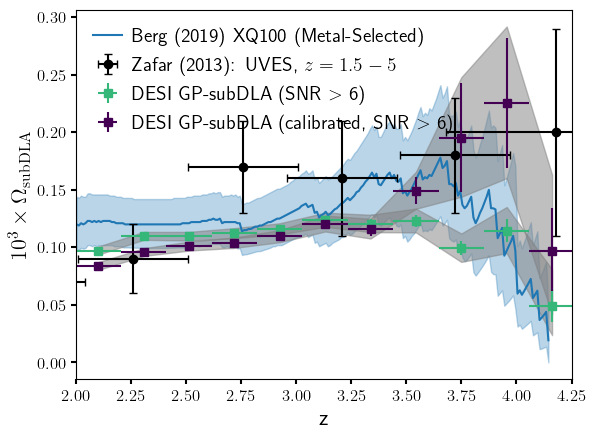

In [124]:
# dla_data.xq100_omega(scaling=1000.0, subdla=True, label="Berg19 XQ100 ")

import pandas as pd

df = pd.read_csv("../../DLA_data/omega_hi_tableB4_metal_selected_sample.csv")

z = df["z"].values

# subDLAs
sub_med = df["OmegaHI_sub_med"].values * 1000.0
sub_lo  = df["OmegaHI_sub_p17"].values * 1000.0
sub_hi  = df["OmegaHI_sub_p83"].values * 1000.0

plt.plot(z, sub_med, label="Berg (2019) XQ100 (Metal-Selected)", color="C0")
plt.fill_between(z, sub_lo, sub_hi, alpha=0.3, color="C0")


# Zafar et al. 2013
dtype = [
    ("z_min", float),
    ("z_max", float),
    ("z_mean_DLA", float),
    ("dz_DLA", float),
    ("dX_DLA", float),
    ("Omega_DLA_1e3", float),
    ("Omega_DLA_err_1e3", float),
    ("N_DLA", int),
    ("z_mean_sub", float),
    ("dz_sub", float),
    ("dX_sub", float),
    ("Omega_sub_1e3", float),
    ("Omega_sub_err_1e3", float),
    ("N_sub", int),
    ("Omega_g_total_1e3", float),
    ("Omega_g_err_1e3", float),
    ("rho_g_1e8", float),
    ("rho_g_err_1e8", float),
]

table = np.array([
    (1.51, 2.00, 1.84, 95.6, 279.4, 0.83, 0.24, 21, 1.80, 29.9,  87.3, 0.07, 0.03,  4, 0.90, 0.20, 1.23, 0.33),
    (2.00, 2.50, 2.27,125.1, 396.6, 0.90, 0.28, 26, 2.26, 49.2, 156.8, 0.09, 0.03, 11, 0.99, 0.29, 1.35, 0.38),
    (2.50, 3.00, 2.73, 87.2, 301.0, 0.96, 0.28, 18, 2.76, 47.1, 162.8, 0.17, 0.04, 24, 1.13, 0.28, 1.54, 0.38),
    (3.00, 3.50, 3.25, 64.8, 239.6, 1.00, 0.28, 18, 3.21, 33.7, 124.5, 0.16, 0.05, 23, 1.16, 0.29, 1.58, 0.39),
    (3.50, 4.00, 3.77, 49.5, 194.6, 0.75, 0.21, 19, 3.72, 23.3,  91.7, 0.18, 0.05, 19, 1.03, 0.21, 1.40, 0.29),
    (4.00, 5.00, 4.20, 23.2,  95.6, 0.76, 0.25, 10, 4.18,  9.9,  41.0, 0.20, 0.09,  8, 0.96, 0.25, 1.31, 0.36),
], dtype=dtype)

# x-axis: mean redshift of sub-DLAs
z = table["z_mean_sub"]
# x-error: half bin width
xerr = 0.5 * (table["z_max"] - table["z_min"])
# y-axis: Omega_sub-DLA
omega = table["Omega_sub_1e3"]
omega_err = table["Omega_sub_err_1e3"]

plt.errorbar(
    z, omega,
    xerr=xerr,
    yerr=omega_err,
    fmt="o",
    capsize=3,
    label="Zafar (2013): UVES, $z=1.5-5$",
    color="black",
)

# OmegaDLA: Fiducial
plot_omega_dla(z_cent_sub, omega_hi_sub, omega68_sub, omega95_sub, color=c_skyline, label="DESI GP-subDLA (SNR $>$ 6)", bins_per_z=5, zmin=2, zmax=4.25)

########### Calibrated OmegaDLA: Fiducial ###########
plot_omega_dla(corr_omega_sub["z_cent"], corr_omega_sub["y_corr"] * 1e3, omega68_corr_sub, omega95_corr_sub, color=c_flatirons, label="DESI GP-subDLA (calibrated, SNR $>$ 6)", bins_per_z=5, zmin=2, zmax=4.25)

# plot_omega_dla(z_cent, omega_dla, omega_dla_68, omega_dla_95, color=c_skyline, label="DESI GP (SNR $>$ 8)", bins_per_z=5, zmin=2, zmax=4.25)

plt.legend(
    loc="upper left",
    fontsize=14,
    frameon=False,
    # ncol=2,
    handlelength=1.5,
    handletextpad=0.5,
)

plt.savefig(
    os.path.join(outfile, "gp_desi_omegasubdla.png"),
    bbox_inches="tight",
    dpi=300,
    # fontsize=16,
    transparent=True,
    pad_inches=0.1,
    facecolor="white",
    edgecolor="none",
)

### LLS: l(z) plot 


In [117]:
import numpy as np

def dndx_to_ellz(z, dndx, omega_m=0.279):
    """
    Convert dN/dX -> ell(z)=dN/dz using:
        dX/dz = (1+z)^2 / E(z),
        E(z) = sqrt(Ωm(1+z)^3 + (1-Ωm))
    """
    z = np.asarray(z, dtype=float)
    dndx = np.asarray(dndx, dtype=float)

    Ez = np.sqrt(omega_m * (1.0 + z)**3 + (1.0 - omega_m))
    dX_dz = (1.0 + z)**2 / Ez
    return dndx * dX_dz

def dndx_bounds_to_ellz(z, bounds, omega_m=0.279):
    """
    Convert absolute bounds [low, high] on dN/dX into bounds on dN/dz.
    """
    z = np.asarray(z, float)
    bounds = np.asarray(bounds, float)

    Ez = np.sqrt(omega_m * (1.0 + z)**3 + (1.0 - omega_m))
    dX_dz = (1.0 + z)**2 / Ez

    ell_low = bounds[:, 0] * dX_dz
    ell_high = bounds[:, 1] * dX_dz
    return np.column_stack([ell_low, ell_high])

In [119]:
# --- raw ---
ell_raw = dndx_to_ellz(z_cent, dNdX, omega_m=0.279)
ell68_raw = dndx_bounds_to_ellz(z_cent, dndx68, omega_m=0.279)
ell95_raw = dndx_bounds_to_ellz(z_cent, dndx95, omega_m=0.279)

# --- calibrated ---
ell_corr = dndx_to_ellz(
    corr_real["z_cent"],
    corr_real["y_corr"],
    omega_m=0.279
)
ell68_corr = dndx_bounds_to_ellz(
    corr_real["z_cent"],
    np.column_stack([corr_real["y68_low_corr"], corr_real["y68_high_corr"]]),
    omega_m=0.279
)
ell95_corr = dndx_bounds_to_ellz(
    corr_real["z_cent"],
    np.column_stack([corr_real["y95_low_corr"], corr_real["y95_high_corr"]]),
    omega_m=0.279
)


In [121]:
# #0 Prochaska+2010; 1 Fumagalli+2013; 2 Crighton+2018; 3 O'Meara+2013; 3# Ribaudo+2011; 4 BOSS/This work
# zleft zright lz lzuperr lzdwerr ref

literature_data = np.loadtxt("../../DLA_data/lofz_literature.txt")

# read columns
zleft = literature_data[:, 0]
zright = literature_data[:, 1]
lz = literature_data[:, 2]
lzuperr = literature_data[:, 3]
lzdwerr = literature_data[:, 4]
ref = literature_data[:, 5].astype(int)

ref_dict = {
    0: "SDSS: Prochaska+2010",
    1: "MagE: Fumagalli+2013",
    2: "GGG: Crighton+2018",
    3: "HST: O'Meara+2013",
    # 4: "Ribaudo+2011",
    4: "BOSS: Fumagalli+2020",
}


# # make plot of literature values
# fig, ax = plt.subplots()    

# for iref in range(5):
#     m = ref == iref
#     if np.any(m):
#         zcen_lit = 0.5 * (zleft[m] + zright[m])
#         ax.errorbar(
#             zcen_lit,
#             lz[m],
#             yerr=[lzdwerr[m], lzuperr[m]],
#             fmt="o",
#             label=ref_dict[iref],
#             capsize=2,
#         )
# plt.legend(fontsize=14)
# plt.xlabel("z")
# plt.ylabel(r"$\ell(z) = dN/dz$")

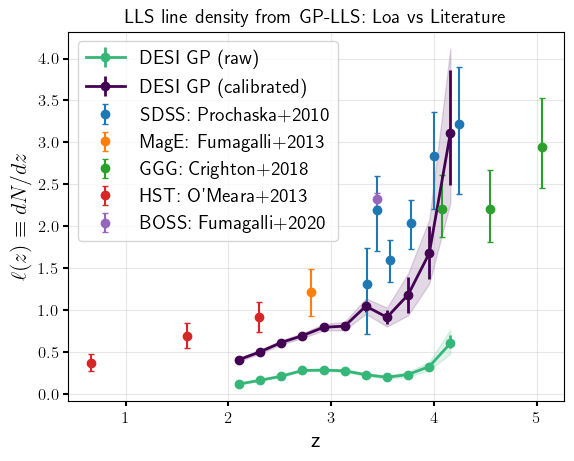

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()


# --- raw ---
ax.errorbar(
    z_cent,
    ell_raw, 
    yerr=[(ell_raw - ell68_raw[:, 0]), (ell68_raw[:, 1] - ell_raw)],
    color=c_skyline, lw=2, label="DESI GP (raw)", marker="o"
)
ax.fill_between(
    z_cent,
    ell95_raw[:, 0], ell95_raw[:, 1],
    color=c_skyline, alpha=0.15
)

# --- calibrated ---
ax.errorbar(
    corr_real["z_cent"],
    ell_corr,
    yerr=[(ell_corr - ell68_corr[:, 0]), (ell68_corr[:, 1] - ell_corr)],
    color=c_flatirons, lw=2, label="DESI GP (calibrated)", marker="o"
)
ax.fill_between(
    corr_real["z_cent"],
    ell95_corr[:, 0], ell95_corr[:, 1],
    color=c_flatirons, alpha=0.15
)

# # --- SNR > 8 calibrated ---
# ax.errorbar(
#     corr_real_highsnr["z_cent"],
#     ell_corr_highsnr,
#     yerr=[(ell_corr_highsnr - ell68_corr_highsnr[:, 0]), (ell68_corr_highsnr[:, 1] - ell_corr_highsnr)],
#     color=c_flatirons_ll, lw=2, label="DESI GP (calibrated, SNR $>$ 8)", marker="o"
# )
# ax.fill_between(
#     corr_real_highsnr["z_cent"],
#     ell95_corr_highsnr[:, 0], ell95_corr_highsnr[:, 1],
#     color=c_flatirons_ll, alpha=0.15
# )

# literature values
# from Michelle Fumagalli's lofz_literature.txt
for iref in range(5):
    m = ref == iref
    if np.any(m):
        zcen_lit = 0.5 * (zleft[m] + zright[m])
        ax.errorbar(
            zcen_lit,
            lz[m],
            yerr=[lzdwerr[m], lzuperr[m]],
            fmt="o",
            label=ref_dict[iref],
            capsize=2,
        )


ax.set_xlabel("z")
ax.set_ylabel(r"$\ell(z) \equiv dN/dz$")
ax.set_title("LLS line density from GP-LLS: Loa vs Literature")
ax.legend(fontsize=14)
ax.grid(True, alpha=0.3)

plt.show()

### DLA: dN/dX

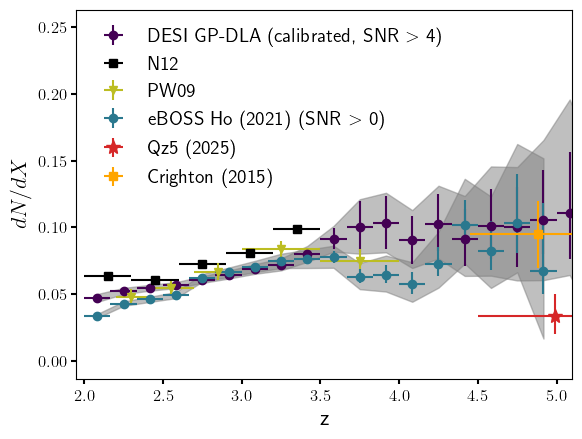

In [160]:

# dN/dX: Fiducial
# plot_line_density(z_cent_dla, dNdX_dla, dndx68_dla, dndx95_dla, color=c_skyline, label="DESI GP-DLA (raw, SNR $>$ 4)", bins_per_z=6)

# Calibrated dN/dX: Fiducial
plot_line_density(corr_real_dla["z_cent"], corr_real_dla["y_corr"], dndx68_corr_dla, dndx95_corr_dla, color=c_flatirons, label="DESI GP-DLA (calibrated, SNR $>$ 4)", bins_per_z=6)

# Load DLA data Noterdaeme 2012, Prochaska 2005
dla_data.dndx_not()
dla_data.dndx_pro()



# dN/dX: Ho 2021
dndx_all = np.loadtxt(os.path.join("../CDDF_analysis/dla_data/ho21/", "dndx_all.txt"))
(_, N) = dndx_all.shape

dndx68 = np.full((N, 2), fill_value=np.nan)
dndx95 = np.full((N, 2), fill_value=np.nan)
(
    z_cent,
    dNdX,
    dndx68[:, 0],
    dndx68[:, 1],
    dndx95[:, 0],
    dndx95[:, 1],
) = dndx_all

plot_line_density(z_cent, dNdX, dndx68, dndx95, zmax=5, color=c_sunshine, label="eBOSS Ho (2021) (SNR $>$ 0)")

# QZ5
xerr= np.array([np.abs(4.5 - 4.99), np.abs(5.57-4.99)])[:, None]
yerr=np.array([np.abs(0.02 - 0.034), np.abs(0.05 - 0.034)])[:, None]
plt.errorbar(np.array([4.99]), np.array([0.034]), yerr=yerr, xerr=xerr, fmt="*", color="C3", label="Qz5 (2025)", markersize=10)

# Crighton et al. (2015)
xerr= np.array([np.abs(4.45 - 4.88), np.abs(5.31-4.88)])[:, None]
yerr=np.array([np.abs(0.12 - 0.095), np.abs(0.07 - 0.095)])[:, None]
plt.errorbar(np.array([4.88]), np.array([0.095]), yerr=yerr, xerr=xerr, fmt="s", color="orange", label="Crighton (2015)")


plt.xlim(1.95, 5.1)
plt.legend(fontsize=12)
plt.ylabel(r"$dN/dX$")
plt.xlabel("z")
# save_figure(os.path.join(outfile, "dndx"))
plt.legend(fontsize=14, frameon=False)
plt.savefig(
    "/Users/jibanmac/Documents/Latex/gp_dla_desi_y3/figures/dndx_dla_completeness_correction.pdf",
    # os.path.join(outfile, "gp_desi_cddf.png"),
    bbox_inches="tight",
    dpi=300,
    # fontsize=16,
    transparent=True,
    pad_inches=0.1,
    facecolor="white",
    edgecolor="none",
    format="pdf",
)

### OmegaDLA

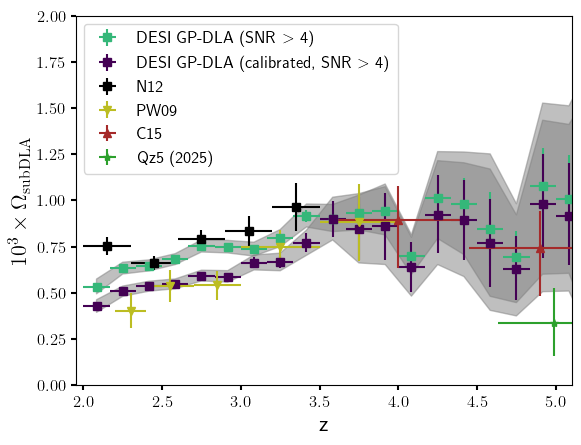

In [158]:
# OmegaDLA: Fiducial
plot_omega_dla(z_cent_dla, omega_hi_dla, omega68_dla, omega95_dla, color=c_skyline, label="DESI GP-DLA (SNR $>$ 4)", bins_per_z=6)

# Calibrated OmegaDLA: Fiducial
plot_omega_dla(corr_omega_dla["z_cent"], corr_omega_dla["y_corr"] * 1e3, omega68_corr_dla, omega95_corr_dla, color=c_flatirons, label="DESI GP-DLA (calibrated, SNR $>$ 4)", bins_per_z=6)

dla_data.omegahi_not()
dla_data.omegahi_pro()
dla_data.crighton_omega()
# dla_data.xq100_omega()

# QZ5
#He divides these measurements by 0.76,
#which he thinks gives him the neutral gas mass in DLAs, because all this hydrogen
#is neutral. However, some of the hydrogen is molecular, so the factor is daft.
#This is rho_crit at z=0
rho_crit = 9.3125685124148235e-30
#This converts from 1e8 M_sun/Mpc^3 to g/cm^3
conv = 6.7699111782945424e-33
#A factor of 0.76 from HI mass to gas mass
#Note: this factor is 0.74, so that the Noterdaeme
#Omega_DLA is numerically similar to the rho_HI of Prochaska
rhohi = np.array([0.56]) # in units of 1e-8 Msun/Mpc^3
factor = conv/rho_crit*1000
omega_DLA = rhohi*factor / 1.2 # HI to DLA conversion factor

xerr= np.array([np.abs(4.5 - 4.99), np.abs(5.57-4.99)])[:, None] *factor
yerr=np.array([np.abs(0.31 - 0.56), np.abs(0.82 - 0.56)])[:, None]*factor

plt.errorbar(np.array([4.99]), omega_DLA, yerr=yerr, xerr=xerr, fmt="*", color="C2", label="Qz5 (2025)")

# # Crighton et al. (2015)
# xerr= np.array([[np.abs(3.56 - 4.01), np.abs(4.45-4.01)],
#                 [np.abs(4.45 - 4.88), np.abs(5.31-4.88)]]) *factor
# yerr=np.array([[np.abs(1.36 - 1.73), np.abs(2.11 - 1.73)],
#                [np.abs(1.19 - 1.44), np.abs(1.73 - 1.44)]]) *factor
# plt.errorbar(np.array([4.01, 4.88]), np.array([1.73, 1.44]) *factor, yerr=yerr, xerr=xerr, fmt="x", color="orange", label="Crighton (2015)")

# # OmegaDLA: Ho2021
# omega_dla_all = np.loadtxt(os.path.join("../CDDF_analysis/dla_data/ho21", "omega_dla_all.txt"))
# (_, N) = omega_dla_all.shape

# omega_dla_68 = np.full((N, 2), fill_value=np.nan)
# omega_dla_95 = np.full((N, 2), fill_value=np.nan)
# (
#     z_cent,
#     omega_dla,
#     omega_dla_68[:, 0],
#     omega_dla_68[:, 1],
#     omega_dla_95[:, 0],
#     omega_dla_95[:, 1],
# ) = omega_dla_all

# plot_omega_dla(z_cent, omega_dla, omega_dla_68, omega_dla_95, zmax=5, color="C2", label="eBOSS Ho (2021) (SNR > 0)")

plt.xlim(1.95, 5.1)
plt.ylim(0, 2.)
plt.legend(fontsize=12)

save_figure(os.path.join(outfile, "omega_dla"))